In [1]:
# Cell 1: Imports & plotting settings
# (Chạy trong Jupyter notebook)
%matplotlib inline
import os
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Load dữ liệu

In [3]:
import pandas as pd

# thay 'ten_file.csv' bằng tên file thật bạn vừa tải lên
df = pd.read_csv("../data/HoaBinh.csv")

# xem kích thước, các cột
print(df.shape)
print(df.columns)
print(df.head())

(34344, 10)
Index(['time', 'temperature_2m (°C)', 'precipitation (mm)',
       'relative_humidity_2m (%)', 'wind_speed_10m (km/h)',
       'et0_fao_evapotranspiration (mm)', 'cloud_cover (%)',
       'surface_pressure (hPa)', 'rain (mm)', 'snowfall (cm)'],
      dtype='object')
               time  temperature_2m (°C)  precipitation (mm)  \
0  2022-01-01T00:00                 15.3                 0.0   
1  2022-01-01T01:00                 15.9                 0.0   
2  2022-01-01T02:00                 16.5                 0.0   
3  2022-01-01T03:00                 16.9                 0.0   
4  2022-01-01T04:00                 17.6                 0.0   

   relative_humidity_2m (%)  wind_speed_10m (km/h)  \
0                        90                    4.0   
1                        87                    4.4   
2                        83                    5.7   
3                        82                    6.8   
4                        79                    7.6   

   et0_fao_

# EDA

## Xử lý tên định dạng lỗi

In [4]:
df.rename(columns={
    'wind_speed_10m (km/h)': 'wind_speed_10m_km_h'
}, inplace=True)


## Loại bỏ các múi giờ thừa

In [5]:
import pandas as pd

# Các giờ cần giữ
#keep_hours = ["02:00:00", "05:00:00", "08:00:00", "11:00:00",
#              "14:00:00", "17:00:00", "20:00:00", "23:00:00"]

# Nếu cột time chưa là datetime thì chuyển sang
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Lọc giữ lại các dòng có giờ nằm trong danh sách
#df = df[df["time"].dt.strftime("%H:%M:%S").isin(keep_hours)]



In [6]:
cols_target = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)','cloud_cover (%)'
]

df.to_csv("../data_clear/HoaBinh/Full/HoaBinh_full.csv", index=False)


df[cols_target].describe()

,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),cloud_cover (%)
count,34344.000000,34344.000000,34344.000000,34344.000000
mean,24.537389,82.607180,0.237060,75.233432
std,5.421226,13.671988,1.059762,36.575230
min,7.400000,19.000000,0.000000,0.000000
25%,20.900000,74.000000,0.000000,48.000000
50%,25.500000,86.000000,0.000000,100.000000
75%,28.200000,94.000000,0.100000,100.000000
max,42.900000,100.000000,39.000000,100.000000


In [7]:
df = df.resample('1D', on='time').mean().reset_index()


In [8]:
print(df.shape)

(1431, 10)


In [39]:
print(df_day.shape)

(1386, 10)


## EDA đơn biến

### Các hàm EDA đơn biến

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# 1️⃣ Thống kê mô tả
def describe_column(df, col):
    """In thống kê cơ bản của cột"""
    print(f"\n🔹 Thống kê mô tả cho cột: {col}")
    print(df[col].describe().round(3))
    print("Số giá trị null:", df[col].isna().sum())

# 2️⃣ Histogram
def plot_histogram(df, col, bins=30, kde=True):
    """Vẽ biểu đồ phân phối (histogram)"""
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=bins, kde=kde, color='steelblue')
    plt.title(f'Phân phối giá trị của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.grid(alpha=0.3)
    plt.show()

# 3️⃣ Boxplot tổng thể
def plot_boxplot(df, col):
    """Vẽ Boxplot để xem ngoại lai"""
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot của {col}')
    plt.xlabel(col)
    plt.grid(alpha=0.3)
    plt.show()

# 4️⃣ Boxplot theo tháng (tháng là category)
def plot_box_by_month(df, time_col, col):
    """Vẽ Boxplot của cột theo tháng trong từng năm"""
    df = df.copy()
    df['month'] = df[time_col].dt.month
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='month', y=col, palette='Blues', showfliers=False)
    plt.title(f'Phân bố {col} theo tháng')
    plt.xlabel('Tháng')
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5️⃣ Hàm tổng hợp EDA đơn biến cho từng năm
def eda_univariate_by_year(df, time_col, col, years=[2022, 2023, 2024, 2025]):
    """EDA đơn biến tổng thể + EDA theo từng năm, với tháng là category"""
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])
    df['year'] = df[time_col].dt.year

    print(f"\n==============================")
    print(f"📊 EDA đơn biến cho cột: {col}")
    print(f"==============================")

    # --- Tổng thể ---
    print("\n📈 Tổng thể toàn bộ dữ liệu:")
    describe_column(df, col)
    plot_histogram(df, col)
    plot_boxplot(df, col)

    # --- Theo từng năm ---
    for y in years:
        if y in df['year'].unique():
            df_year = df[df['year'] == y]
            print(f"\n📅 Năm {y} — {col}")
            describe_column(df_year, col)
            plot_histogram(df_year, col)
            plot_box_by_month(df_year, time_col, col)
        else:
            print(f"⚠️ Không có dữ liệu cho năm {y}.")

# 6️⃣ Hàm chạy toàn bộ EDA cho danh sách cột
def run_univariate_eda(df, cols_target, time_col='time'):
    """Chạy EDA đơn biến cho toàn bộ các cột trong danh sách"""
    for col in cols_target:
        eda_univariate_by_year(df, time_col, col)


### Kết quả


📊 EDA đơn biến cho cột: temperature_2m (°C)

📈 Tổng thể toàn bộ dữ liệu:

🔹 Thống kê mô tả cho cột: temperature_2m (°C)
count    1431.000
mean       24.537
std         4.901
min         8.967
25%        21.160
50%        25.879
75%        28.208
max        33.613
Name: temperature_2m (°C), dtype: float64
Số giá trị null: 0


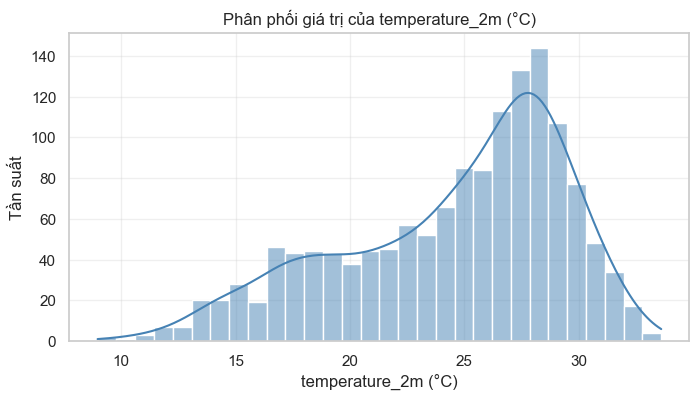

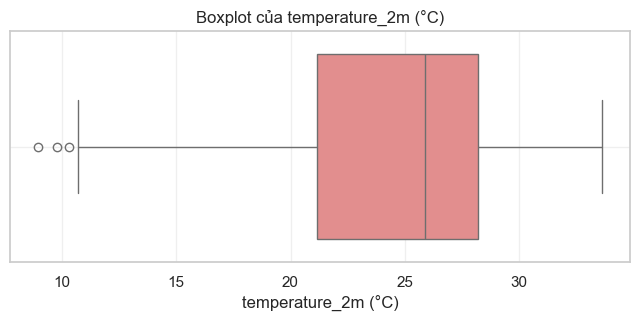


📅 Năm 2022 — temperature_2m (°C)

🔹 Thống kê mô tả cho cột: temperature_2m (°C)
count    365.000
mean      23.837
std        5.018
min        8.967
25%       20.408
50%       25.012
75%       27.679
max       31.583
Name: temperature_2m (°C), dtype: float64
Số giá trị null: 0


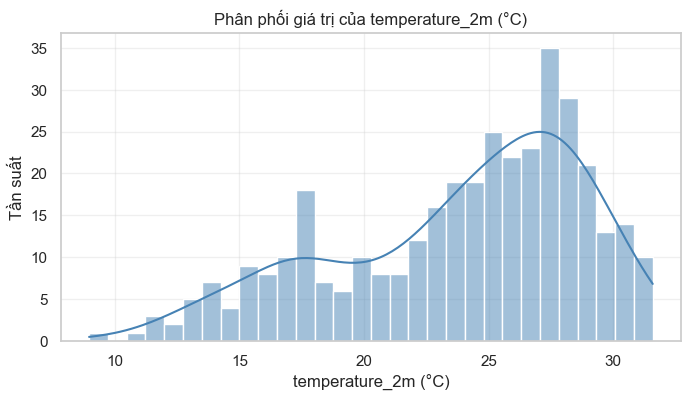

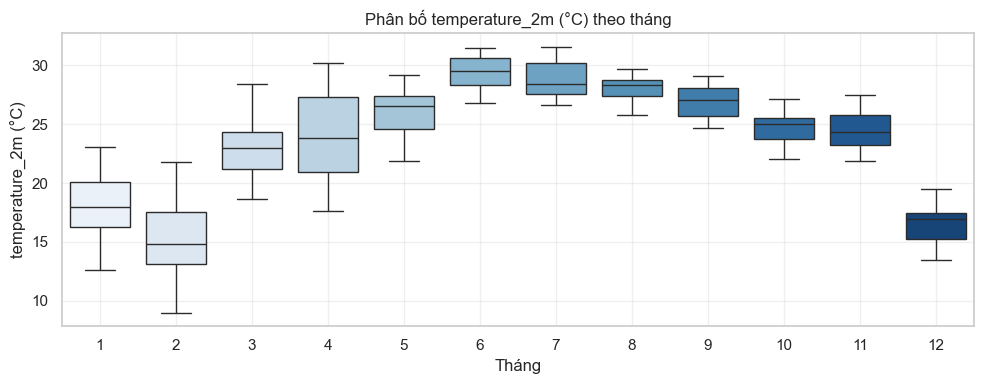


📅 Năm 2023 — temperature_2m (°C)

🔹 Thống kê mô tả cho cột: temperature_2m (°C)
count    365.000
mean      24.889
std        4.781
min       11.946
25%       21.475
50%       26.096
75%       28.533
max       33.500
Name: temperature_2m (°C), dtype: float64
Số giá trị null: 0


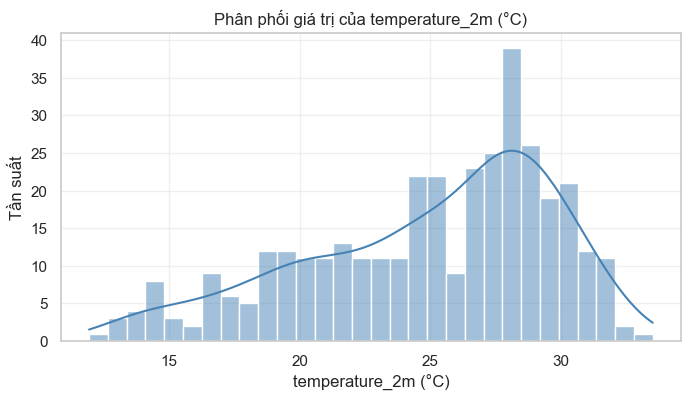

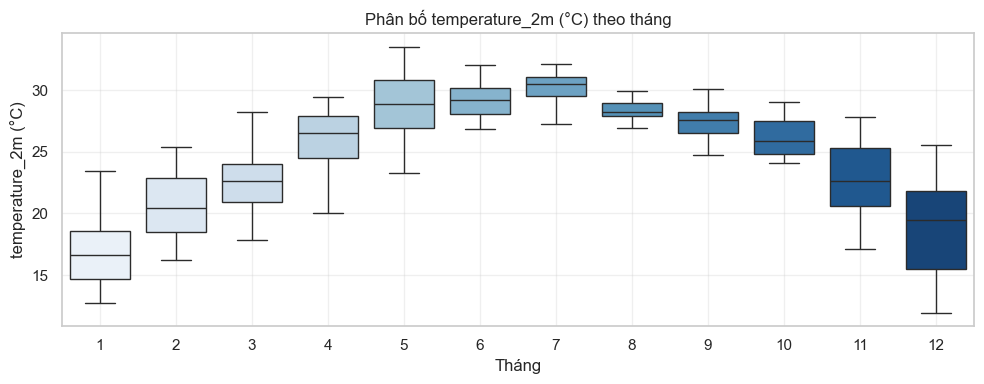


📅 Năm 2024 — temperature_2m (°C)

🔹 Thống kê mô tả cho cột: temperature_2m (°C)
count    366.000
mean      24.918
std        4.892
min        9.779
25%       22.078
50%       26.444
75%       28.362
max       33.613
Name: temperature_2m (°C), dtype: float64
Số giá trị null: 0


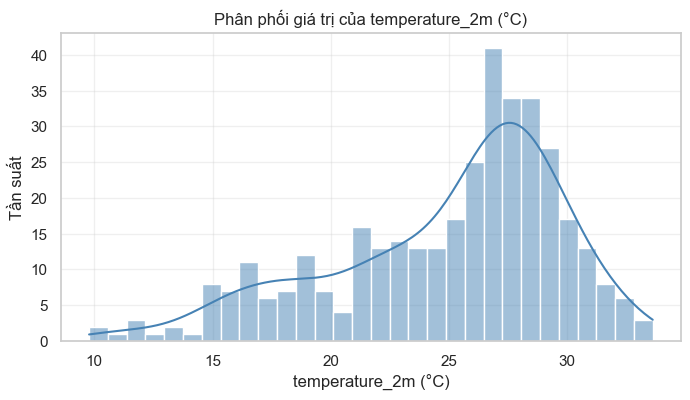

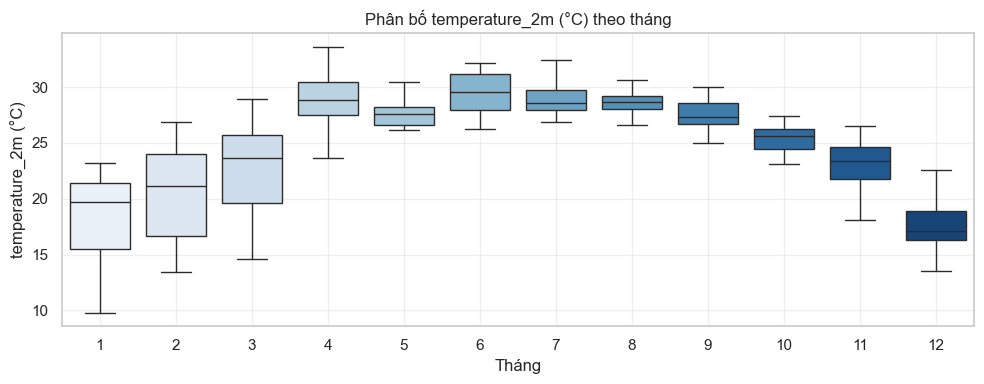


📅 Năm 2025 — temperature_2m (°C)

🔹 Thống kê mô tả cho cột: temperature_2m (°C)
count    335.000
mean      24.501
std        4.850
min       13.079
25%       20.540
50%       25.875
75%       28.283
max       32.317
Name: temperature_2m (°C), dtype: float64
Số giá trị null: 0


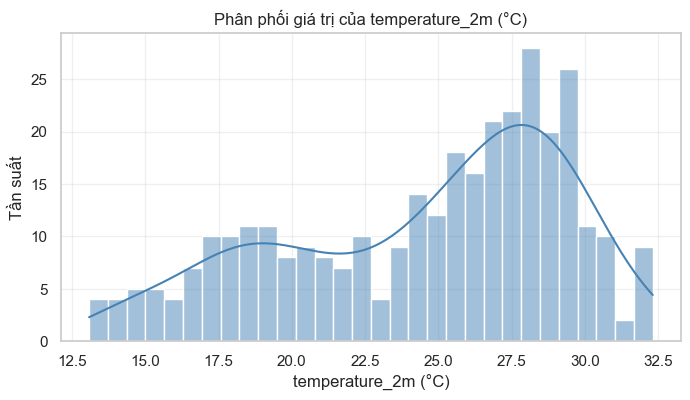

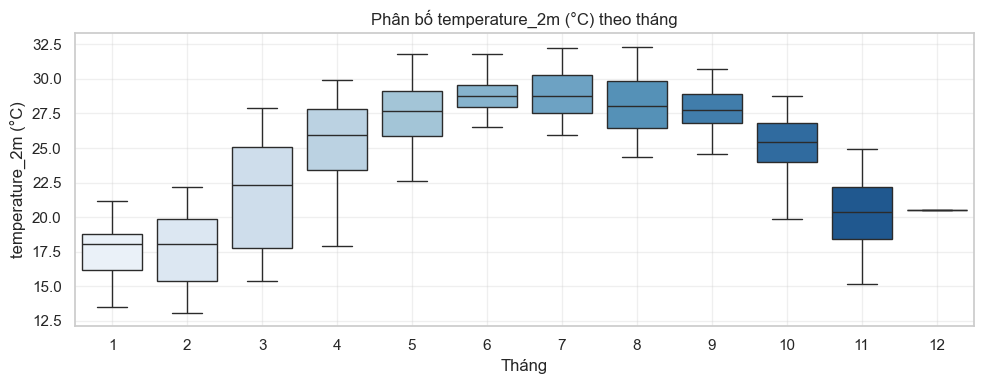


📊 EDA đơn biến cho cột: relative_humidity_2m (%)

📈 Tổng thể toàn bộ dữ liệu:

🔹 Thống kê mô tả cho cột: relative_humidity_2m (%)
count    1431.000
mean       82.607
std         7.465
min        45.583
25%        78.604
50%        84.042
75%        87.833
max        97.958
Name: relative_humidity_2m (%), dtype: float64
Số giá trị null: 0


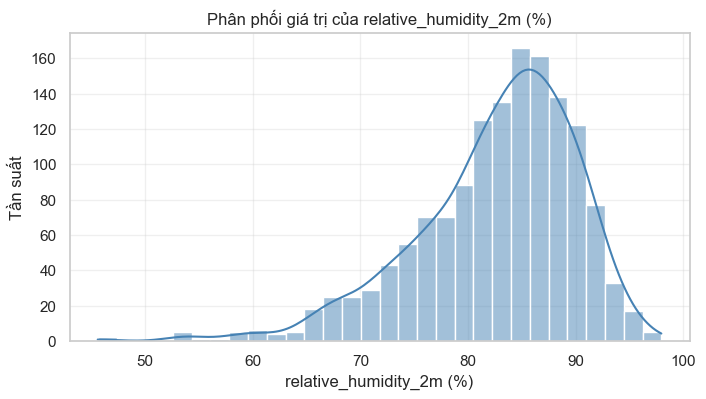

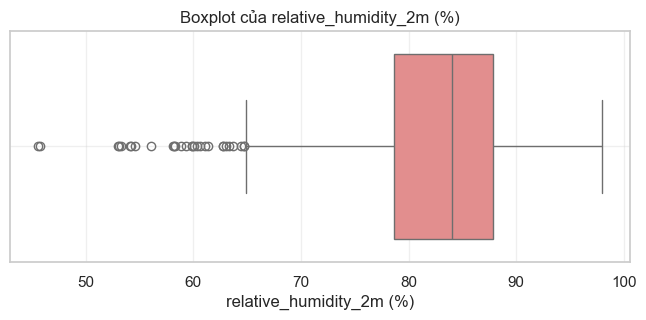


📅 Năm 2022 — relative_humidity_2m (%)

🔹 Thống kê mô tả cho cột: relative_humidity_2m (%)
count    365.000
mean      83.093
std        7.334
min       45.583
25%       79.833
50%       84.542
75%       88.208
max       95.750
Name: relative_humidity_2m (%), dtype: float64
Số giá trị null: 0


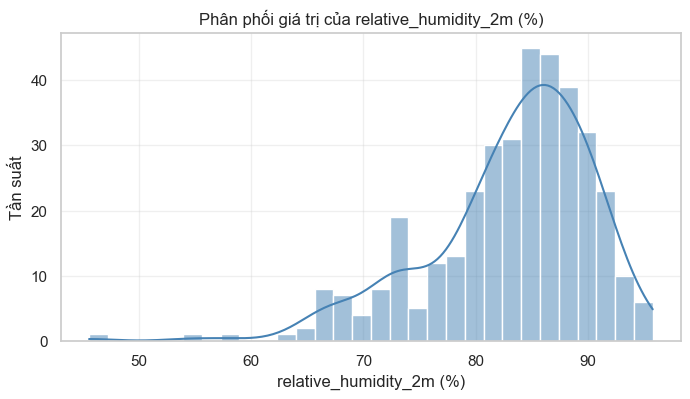

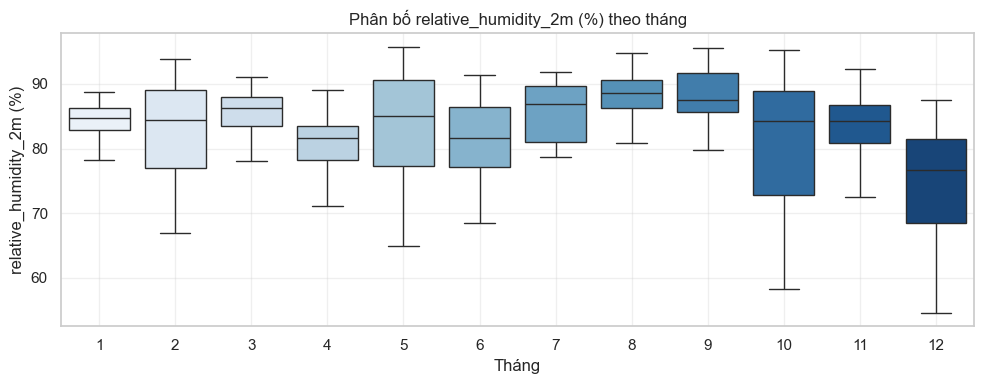


📅 Năm 2023 — relative_humidity_2m (%)

🔹 Thống kê mô tả cho cột: relative_humidity_2m (%)
count    365.000
mean      81.088
std        7.787
min       53.125
25%       77.542
50%       82.125
75%       86.333
max       94.750
Name: relative_humidity_2m (%), dtype: float64
Số giá trị null: 0


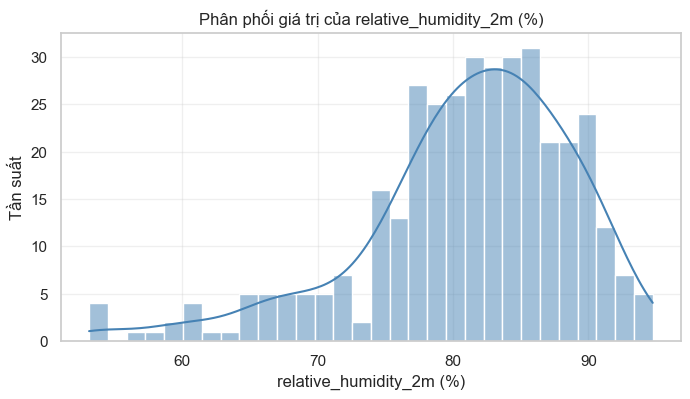

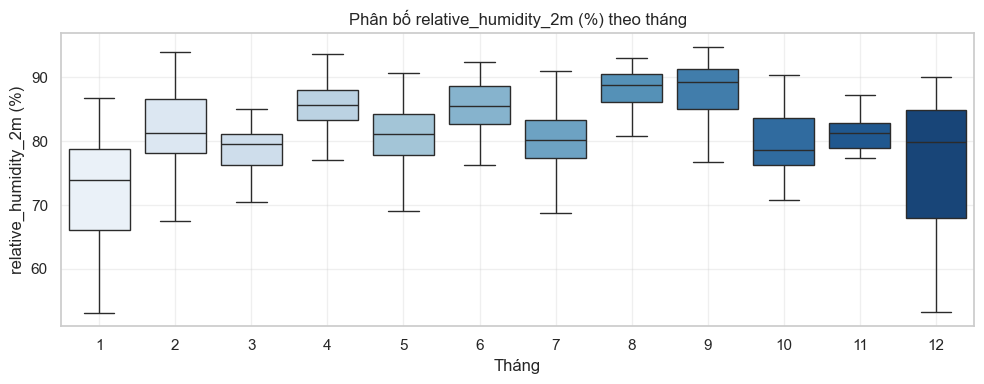


📅 Năm 2024 — relative_humidity_2m (%)

🔹 Thống kê mô tả cho cột: relative_humidity_2m (%)
count    366.000
mean      82.983
std        6.929
min       45.750
25%       79.510
50%       84.167
75%       88.083
max       94.875
Name: relative_humidity_2m (%), dtype: float64
Số giá trị null: 0


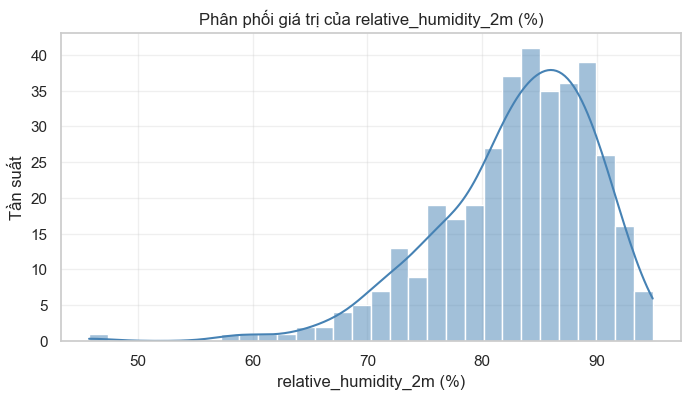

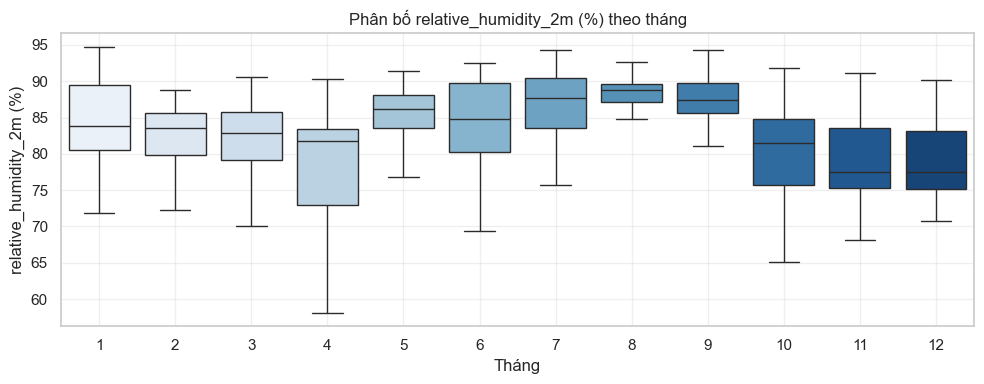


📅 Năm 2025 — relative_humidity_2m (%)

🔹 Thống kê mô tả cho cột: relative_humidity_2m (%)
count    335.000
mean      83.322
std        7.613
min       53.042
25%       78.271
50%       84.667
75%       88.812
max       97.958
Name: relative_humidity_2m (%), dtype: float64
Số giá trị null: 0


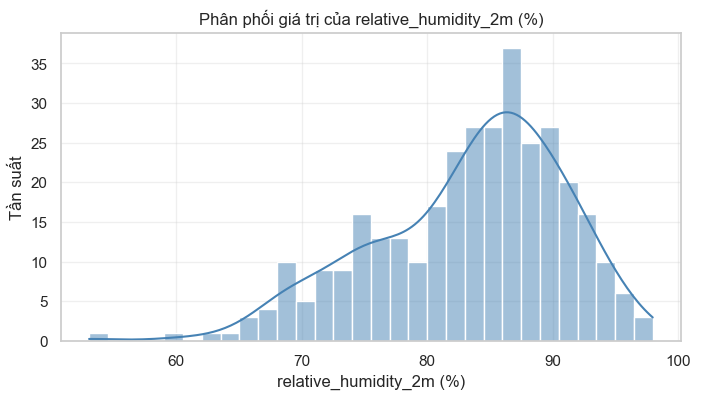

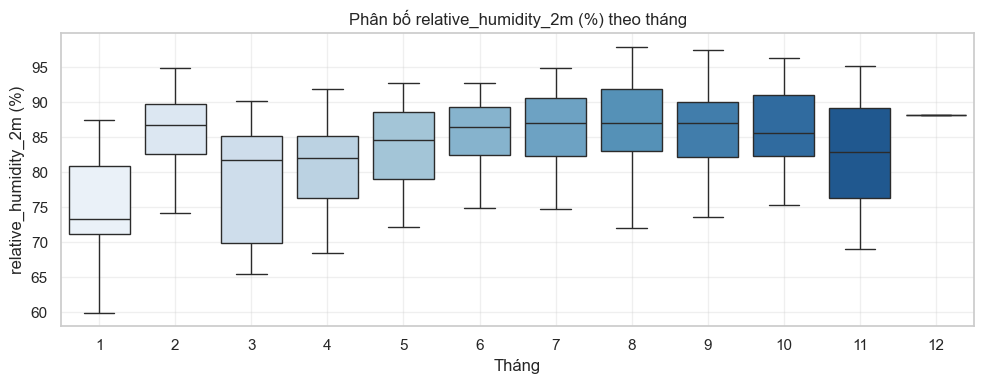


📊 EDA đơn biến cho cột: precipitation (mm)

📈 Tổng thể toàn bộ dữ liệu:

🔹 Thống kê mô tả cho cột: precipitation (mm)
count    1431.000
mean        0.237
std         0.524
min         0.000
25%         0.000
50%         0.029
75%         0.233
max         7.183
Name: precipitation (mm), dtype: float64
Số giá trị null: 0


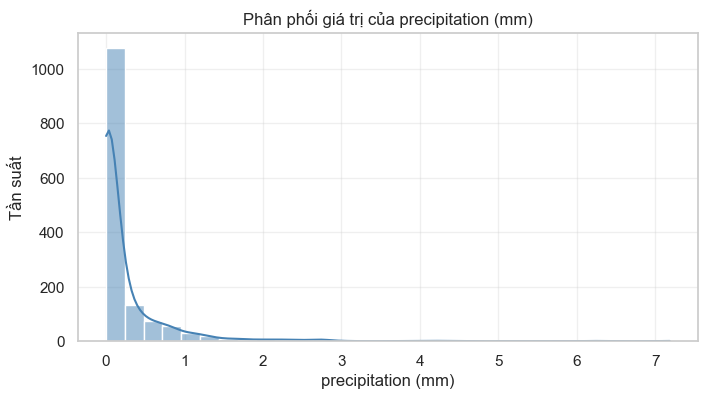

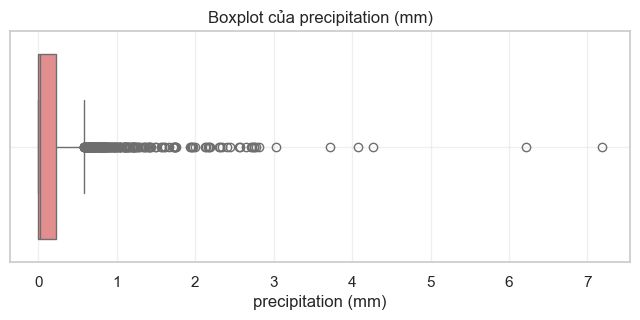


📅 Năm 2022 — precipitation (mm)

🔹 Thống kê mô tả cho cột: precipitation (mm)
count    365.000
mean       0.260
std        0.588
min        0.000
25%        0.000
50%        0.038
75%        0.271
max        7.183
Name: precipitation (mm), dtype: float64
Số giá trị null: 0


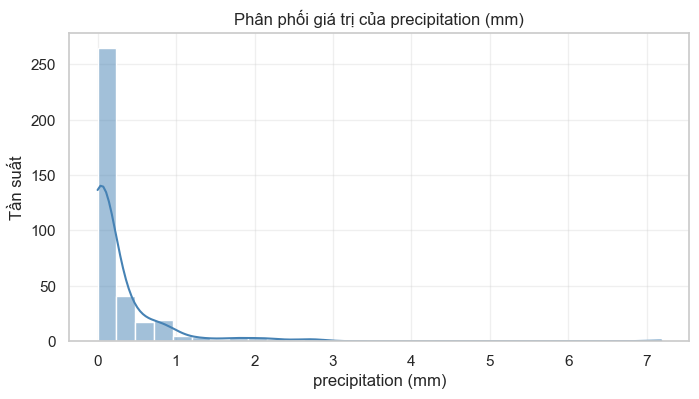

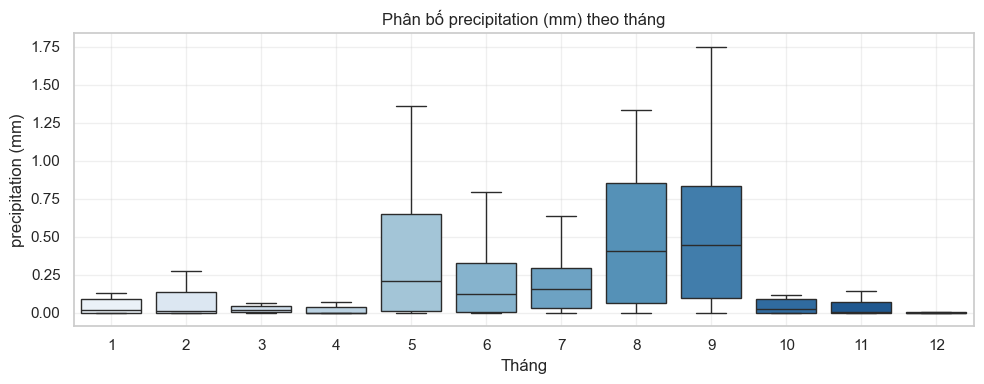


📅 Năm 2023 — precipitation (mm)

🔹 Thống kê mô tả cho cột: precipitation (mm)
count    365.000
mean       0.184
std        0.405
min        0.000
25%        0.000
50%        0.017
75%        0.171
max        2.812
Name: precipitation (mm), dtype: float64
Số giá trị null: 0


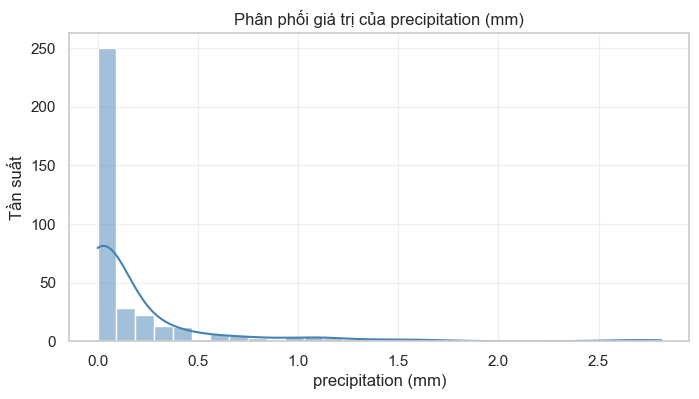

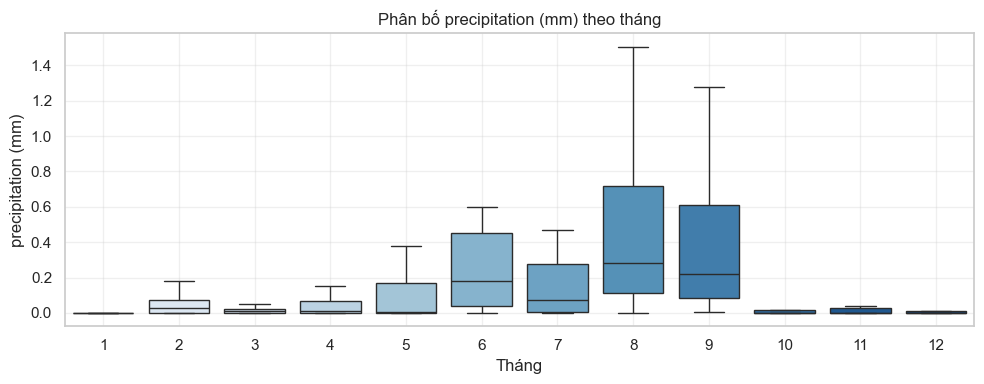


📅 Năm 2024 — precipitation (mm)

🔹 Thống kê mô tả cho cột: precipitation (mm)
count    366.000
mean       0.248
std        0.555
min        0.000
25%        0.000
50%        0.029
75%        0.229
max        6.212
Name: precipitation (mm), dtype: float64
Số giá trị null: 0


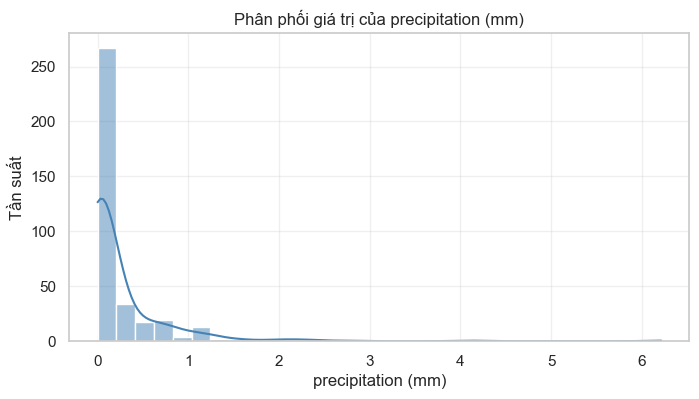

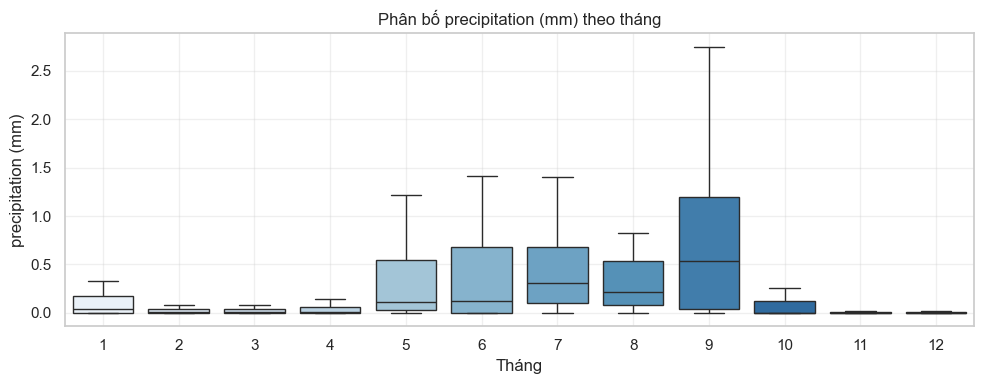


📅 Năm 2025 — precipitation (mm)

🔹 Thống kê mô tả cho cột: precipitation (mm)
count    335.000
mean       0.257
std        0.528
min        0.000
25%        0.000
50%        0.033
75%        0.273
max        4.262
Name: precipitation (mm), dtype: float64
Số giá trị null: 0


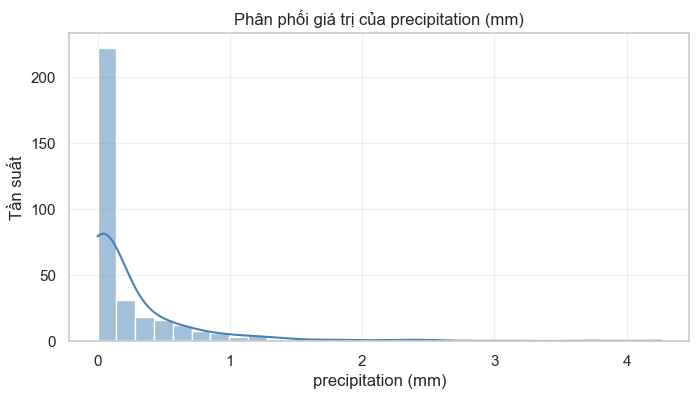

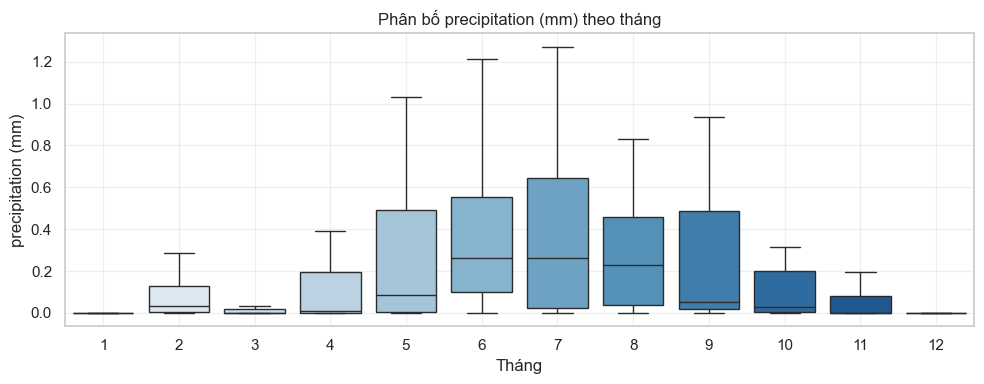


📊 EDA đơn biến cho cột: cloud_cover (%)

📈 Tổng thể toàn bộ dữ liệu:

🔹 Thống kê mô tả cho cột: cloud_cover (%)
count    1431.000
mean       75.233
std        27.575
min         0.000
25%        57.417
50%        87.250
75%        99.229
max       100.000
Name: cloud_cover (%), dtype: float64
Số giá trị null: 0


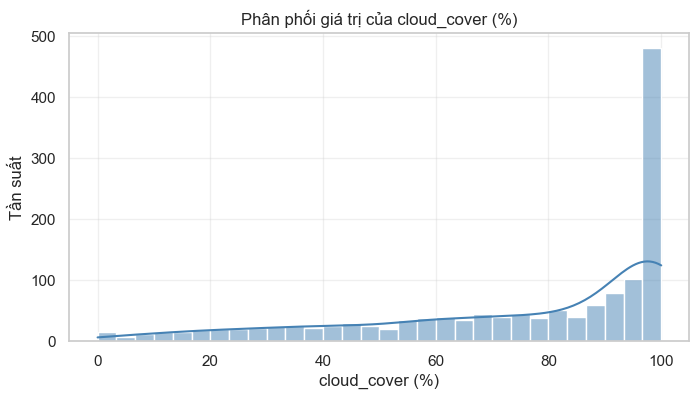

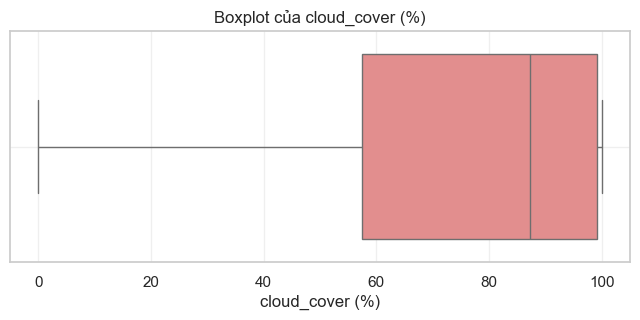


📅 Năm 2022 — cloud_cover (%)

🔹 Thống kê mô tả cho cột: cloud_cover (%)
count    365.000
mean      75.922
std       27.551
min        2.000
25%       57.833
50%       87.542
75%       99.708
max      100.000
Name: cloud_cover (%), dtype: float64
Số giá trị null: 0


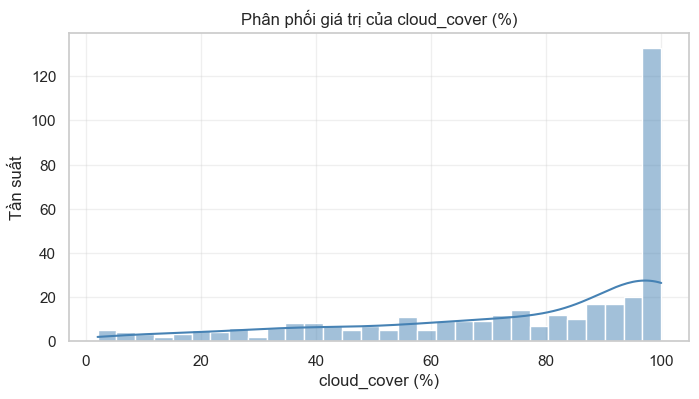

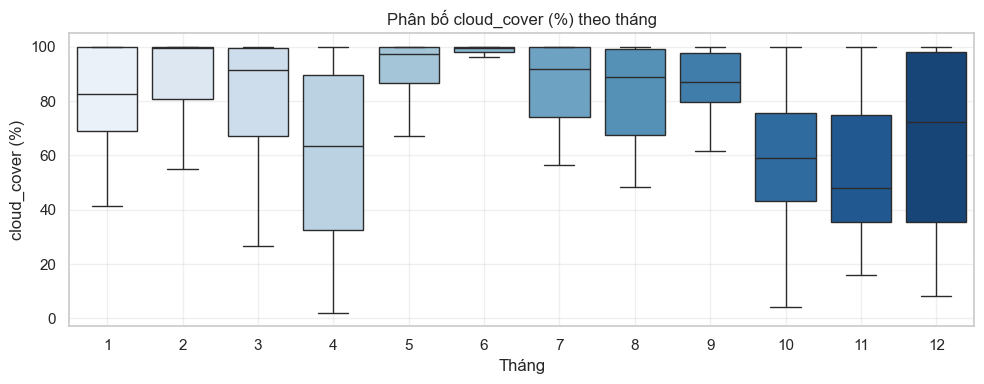


📅 Năm 2023 — cloud_cover (%)

🔹 Thống kê mô tả cho cột: cloud_cover (%)
count    365.000
mean      71.991
std       28.500
min        0.042
25%       52.208
50%       80.083
75%       98.083
max      100.000
Name: cloud_cover (%), dtype: float64
Số giá trị null: 0


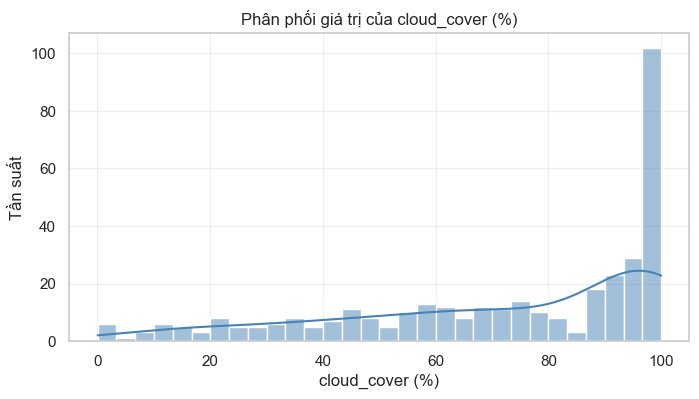

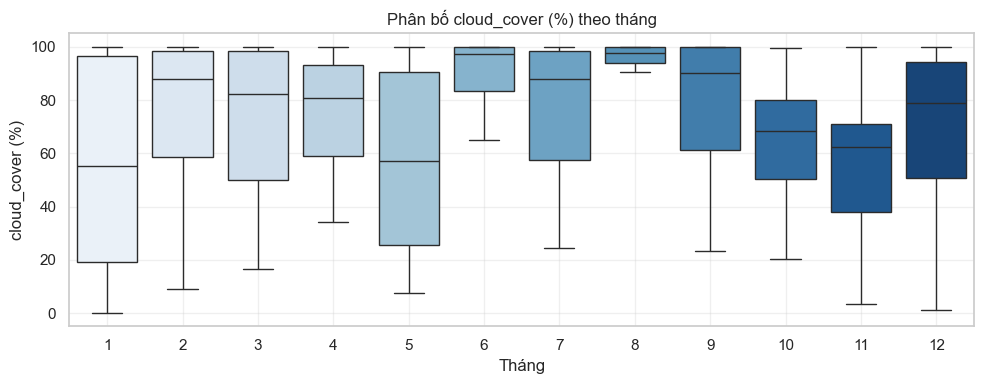


📅 Năm 2024 — cloud_cover (%)

🔹 Thống kê mô tả cho cột: cloud_cover (%)
count    366.000
mean      75.757
std       26.895
min        0.000
25%       57.542
50%       85.333
75%       99.490
max      100.000
Name: cloud_cover (%), dtype: float64
Số giá trị null: 0


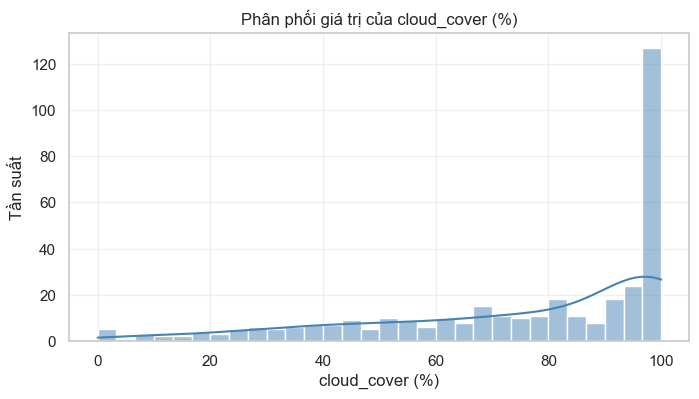

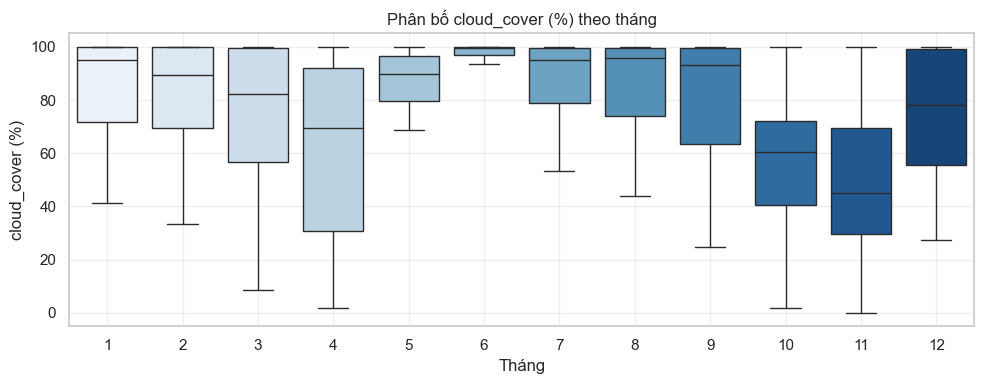


📅 Năm 2025 — cloud_cover (%)

🔹 Thống kê mô tả cho cột: cloud_cover (%)
count    335.000
mean      77.444
std       27.118
min        2.042
25%       62.979
50%       89.750
75%       99.167
max      100.000
Name: cloud_cover (%), dtype: float64
Số giá trị null: 0


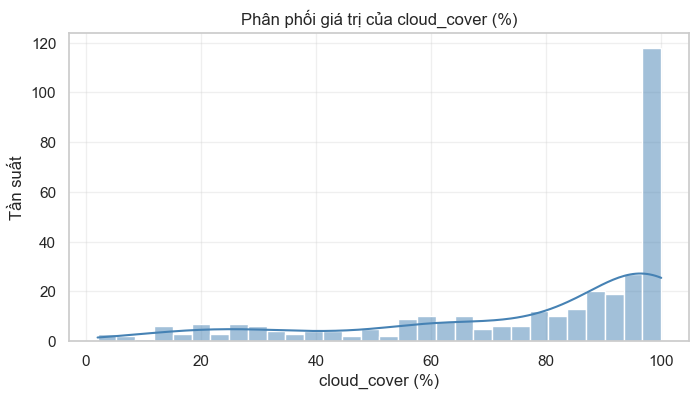

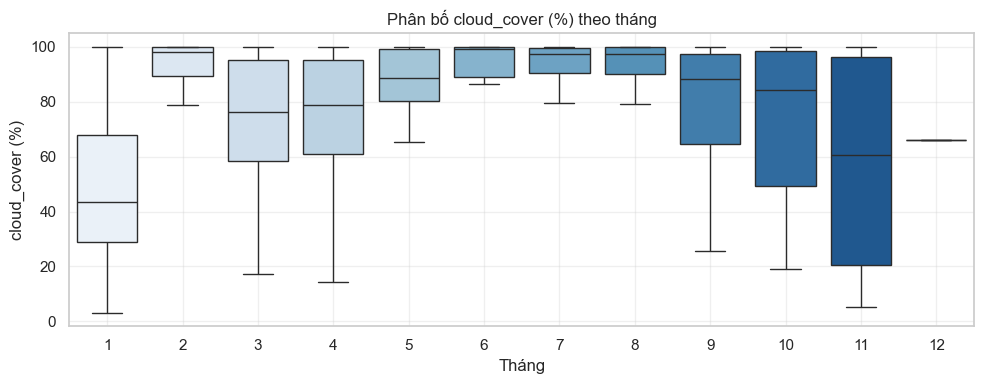

In [10]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

# Đảm bảo cột time là datetime
df['time'] = pd.to_datetime(df['time'])

# Chạy EDA toàn bộ
run_univariate_eda(df, cols_target, time_col='time')


### Lưu file

#### Hàm lưu

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# -------------------------------
# 🧱 Hàm hỗ trợ
# -------------------------------
def save_plot(fig, folder, filename):
    """Lưu biểu đồ vào thư mục"""
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)
    fig.savefig(filepath, bbox_inches='tight')
    plt.close(fig)

# -------------------------------
# 📊 Thống kê mô tả
# -------------------------------
def describe_and_save(df, col, folder, filename):
    """Lưu thống kê mô tả ra CSV"""
    os.makedirs(folder, exist_ok=True)
    stats = df[col].describe().to_frame().T
    stats["null_count"] = df[col].isna().sum()
    filepath = os.path.join(folder, filename)
    stats.to_csv(filepath, index=False, mode='a', header=not os.path.exists(filepath))
    return stats

# -------------------------------
# 📈 Biểu đồ đơn biến
# -------------------------------
def eda_univariate_by_year_save(df, time_col, col,
                                years=[2022, 2023, 2024, 2025],
                                output_folder="EDA_Output"):
    """
    EDA đơn biến tổng thể + từng năm (tháng là category)
    -> Lưu toàn bộ biểu đồ và thống kê ra file
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])
    df['year'] = df[time_col].dt.year
    df['month'] = df[time_col].dt.month

    print(f"\n==============================")
    print(f"📊 EDA đơn biến cho cột: {col}")
    print(f"==============================")

    col_folder = os.path.join(output_folder, col.replace(" ", "_"))

    # 1️⃣ Tổng thể
    print("\n📈 Tổng thể toàn bộ dữ liệu:")
    stats = describe_and_save(df, col, col_folder, f"{col}_stats.csv")

    # Histogram tổng thể
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(f'Phân phối {col} (Tổng thể)')
    save_plot(fig, col_folder, f"{col}_hist_all.png")

    # Boxplot tổng thể
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.boxplot(x=df[col], color='lightcoral', ax=ax)
    ax.set_title(f'Boxplot {col} (Tổng thể)')
    save_plot(fig, col_folder, f"{col}_box_all.png")

    # 2️⃣ Theo từng năm
    for y in years:
        if y in df['year'].unique():
            df_year = df[df['year'] == y]
            year_folder = os.path.join(col_folder, str(y))
            print(f"\n📅 Năm {y} — {col}")

            describe_and_save(df_year, col, year_folder, f"{col}_stats_{y}.csv")

            # Histogram
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.histplot(df_year[col], bins=30, kde=True, color='steelblue', ax=ax)
            ax.set_title(f'Phân phối {col} — Năm {y}')
            save_plot(fig, year_folder, f"{col}_hist_{y}.png")

            # Boxplot theo tháng
            fig, ax = plt.subplots(figsize=(10, 4))
            sns.boxplot(data=df_year, x='month', y=col, palette='Blues', showfliers=False, ax=ax)
            ax.set_title(f'Phân bố {col} theo tháng — Năm {y}')
            save_plot(fig, year_folder, f"{col}_box_month_{y}.png")
        else:
            print(f"⚠️ Không có dữ liệu cho năm {y}.")

# -------------------------------
# 🚀 Chạy toàn bộ cho danh sách cột
# -------------------------------
def run_univariate_eda_save(df, cols_target, time_col='time', output_folder="EDA_Output"):
    """Chạy EDA đơn biến cho toàn bộ các cột và lưu kết quả"""
    os.makedirs(output_folder, exist_ok=True)
    for col in cols_target:
        eda_univariate_by_year_save(df, time_col, col, output_folder=output_folder)


#### Tiến hành lưu

In [12]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

df['time'] = pd.to_datetime(df['time'])

run_univariate_eda_save(df, cols_target, time_col='time', output_folder="../plot/HoaBinh/DonBien")



📊 EDA đơn biến cho cột: temperature_2m (°C)

📈 Tổng thể toàn bộ dữ liệu:

📅 Năm 2022 — temperature_2m (°C)

📅 Năm 2023 — temperature_2m (°C)

📅 Năm 2024 — temperature_2m (°C)

📅 Năm 2025 — temperature_2m (°C)

📊 EDA đơn biến cho cột: relative_humidity_2m (%)

📈 Tổng thể toàn bộ dữ liệu:

📅 Năm 2022 — relative_humidity_2m (%)

📅 Năm 2023 — relative_humidity_2m (%)

📅 Năm 2024 — relative_humidity_2m (%)

📅 Năm 2025 — relative_humidity_2m (%)

📊 EDA đơn biến cho cột: precipitation (mm)

📈 Tổng thể toàn bộ dữ liệu:

📅 Năm 2022 — precipitation (mm)

📅 Năm 2023 — precipitation (mm)

📅 Năm 2024 — precipitation (mm)

📅 Năm 2025 — precipitation (mm)

📊 EDA đơn biến cho cột: cloud_cover (%)

📈 Tổng thể toàn bộ dữ liệu:

📅 Năm 2022 — cloud_cover (%)

📅 Năm 2023 — cloud_cover (%)

📅 Năm 2024 — cloud_cover (%)

📅 Năm 2025 — cloud_cover (%)


## EDA đa biến

In [13]:
time_cols = ['time']

### Các hàm EDA đa biến cần thiết

#### Biểu đồ theo thời gian

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_time_series(df, time_col, value_col,
                     smooth_window=8,        # cửa sổ trung bình trượt (ví dụ 8 điểm)
                     line_color='tab:blue',
                     figsize=(18, 7.5)):
    """
    Vẽ biểu đồ theo thời gian KHÔNG cần resample trước.
    - Giữ dữ liệu gốc (ví dụ 8 điểm/ngày)
    - Làm mượt dữ liệu bằng rolling mean (window = smooth_window)
    """

    sns.set_style("whitegrid")

    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])

    # Sắp xếp theo thời gian (phòng trường hợp dữ liệu chưa đúng thứ tự)
    df = df.sort_values(by=time_col)

    # Làm mượt bằng rolling mean
    df[f'{value_col}_smooth'] = df[value_col].rolling(window=smooth_window, min_periods=1).mean()

    # Vẽ biểu đồ
    plt.figure(figsize=figsize)
    plt.plot(df[time_col], df[value_col],
             color=line_color, alpha=0.25, label='Giá trị gốc')
    plt.plot(df[time_col], df[f'{value_col}_smooth'],
             color='tab:orange', lw=2, label=f'Rolling mean ({smooth_window})')

    plt.title(f'{value_col} theo thời gian ({time_col})', fontsize=13, weight='bold')
    plt.xlabel('Thời gian')
    plt.ylabel(value_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#### Scatter

In [15]:
# 2️⃣ Scatter giữa hai biến số
def plot_scatter(df, col_x, col_y):
    """Vẽ biểu đồ phân tán giữa hai biến định lượng"""
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=col_x, y=col_y, alpha=0.6, color='teal')
    sns.regplot(data=df, x=col_x, y=col_y, scatter=False, color='red')
    plt.title(f'Mối quan hệ giữa {col_x} và {col_y}')
    plt.grid(alpha=0.3)
    plt.show()

#### Ma trận tương quan

In [17]:
# 3️⃣ Ma trận tương quan (Correlation Heatmap)
def plot_correlation_matrix(df, numeric_cols=None, method='pearson'):
    """Vẽ heatmap tương quan giữa các biến numeric"""
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    corr = df[numeric_cols].corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title(f'Ma trận tương quan ({method.title()} correlation)')
    plt.show()
    return corr


#### Pairplot

In [18]:
# 4️⃣ Biểu đồ tương quan từng cặp (Pairplot)
def plot_pairwise_correlation(df, numeric_cols=None):
    """Vẽ pairplot giữa các biến số để xem mối quan hệ từng cặp"""
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True)
    plt.suptitle('Biểu đồ tương quan từng cặp biến số', y=1.02)
    plt.show()

#### Tổng hợp

In [19]:


# 5️⃣ Hàm tổng hợp EDA đa biến (tự chọn loại vẽ)
def eda_bivariate(df, col_x, col_y):
    """
    Tự động chọn loại biểu đồ phù hợp:
    - Nếu col_x là thời gian → vẽ Time Series
    - Nếu cả 2 là numeric → Scatter
    """
    print(f"🔸 Phân tích mối quan hệ: {col_x} vs {col_y}")
    
    if pd.api.types.is_datetime64_any_dtype(df[col_x]):
        plot_time_series(df, col_x, col_y)
    elif pd.api.types.is_numeric_dtype(df[col_x]) and pd.api.types.is_numeric_dtype(df[col_y]):
        plot_scatter(df, col_x, col_y)
    else:
        print("⚠️ Bỏ qua vì không phải numeric hoặc time.")


### EDA thời gian

#### Các hàm

In [20]:
sns.set_style("whitegrid")
def plot_time_series(df, time_col, value_col, smooth_window=8):
    """
    Vẽ biểu đồ theo thời gian (time series) với rolling mean.
    Giữ dữ liệu gốc + làm mượt bằng trung bình trượt (rolling mean).
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])

    df = df.sort_values(by=time_col)
    df[f'{value_col}_smooth'] = df[value_col].rolling(window=smooth_window, min_periods=1).mean()

    plt.figure(figsize=(12, 5))
    plt.plot(df[time_col], df[value_col], alpha=0.25, label='Giá trị gốc', color='tab:blue')
    plt.plot(df[time_col], df[f'{value_col}_smooth'], color='tab:orange', lw=2, label=f'Rolling mean ({smooth_window})')

    plt.title(f'{value_col} theo thời gian', fontsize=13, weight='bold')
    plt.xlabel('Thời gian')
    plt.ylabel(value_col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [21]:
def run_time_eda(df, cols_target, time_col='time', years=[2022, 2023, 2024, 2025]):
    """
    Chạy EDA theo thời gian (time series) cho từng cột trong cols_target,
    và tách riêng theo từng năm (2022–2025).
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])

    df['year'] = df[time_col].dt.year

    for col in cols_target:
        print(f"\n==============================")
        print(f"📊 EDA THEO THỜI GIAN: {col}")
        print(f"==============================")

        # --- Tổng thể ---
        print(f"➡️ Toàn bộ dữ liệu ({col})")
        plot_time_series(df, time_col, col, smooth_window=8)

        # --- Theo từng năm ---
        for y in years:
            if y in df['year'].unique():
                print(f"\n📅 Năm {y} — cột {col}")
                df_year = df[df['year'] == y]
                plot_time_series(df_year, time_col, col, smooth_window=8)
            else:
                print(f"⚠️ Không có dữ liệu cho năm {y}.")


#### Kết quả


📊 EDA THEO THỜI GIAN: temperature_2m (°C)
➡️ Toàn bộ dữ liệu (temperature_2m (°C))


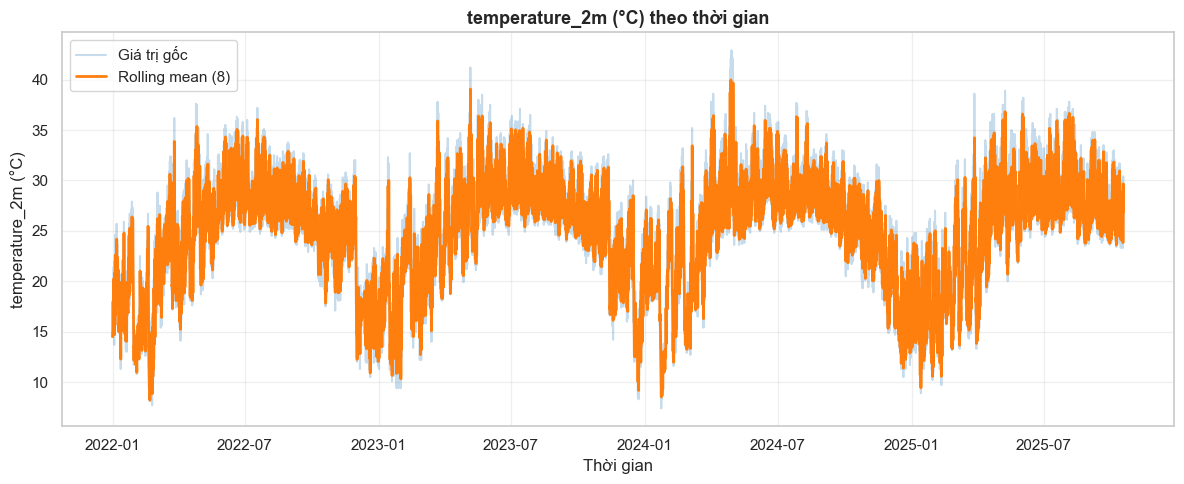


📅 Năm 2022 — cột temperature_2m (°C)


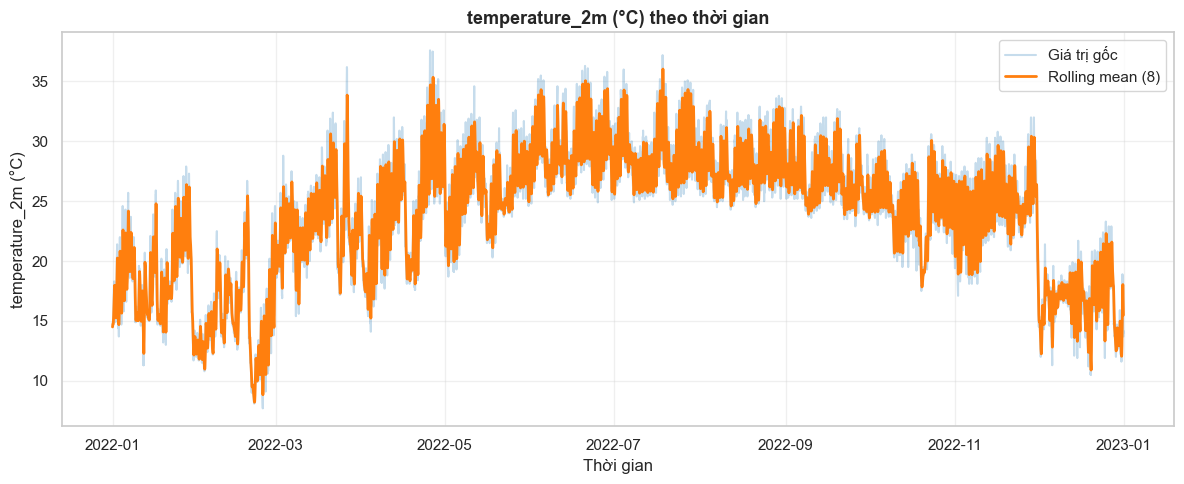


📅 Năm 2023 — cột temperature_2m (°C)


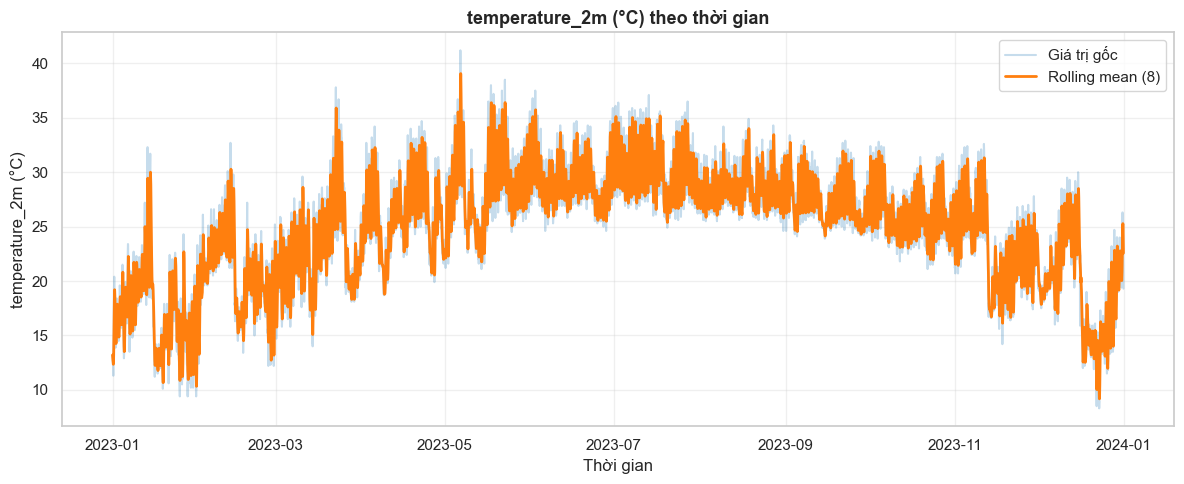


📅 Năm 2024 — cột temperature_2m (°C)


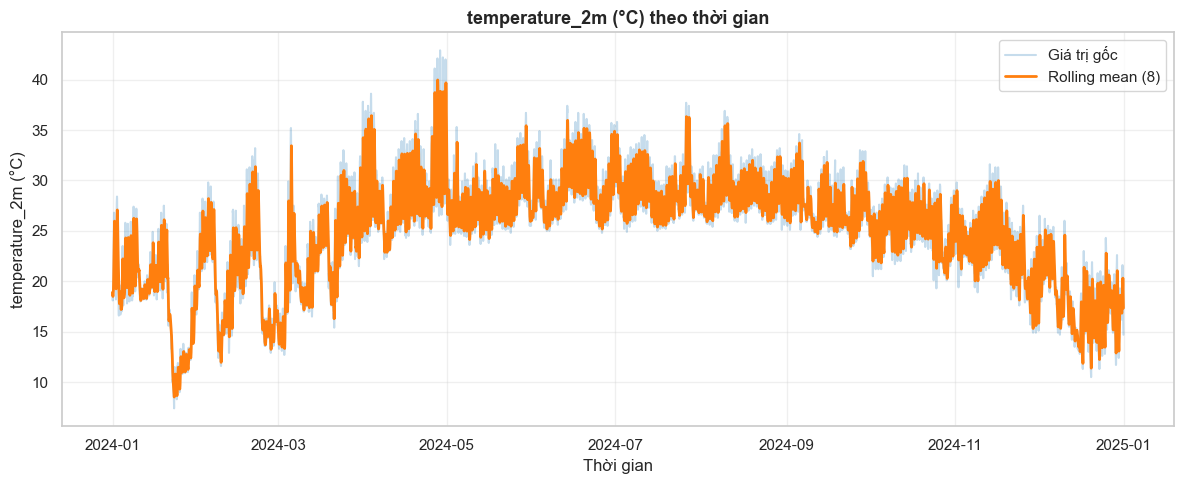


📅 Năm 2025 — cột temperature_2m (°C)


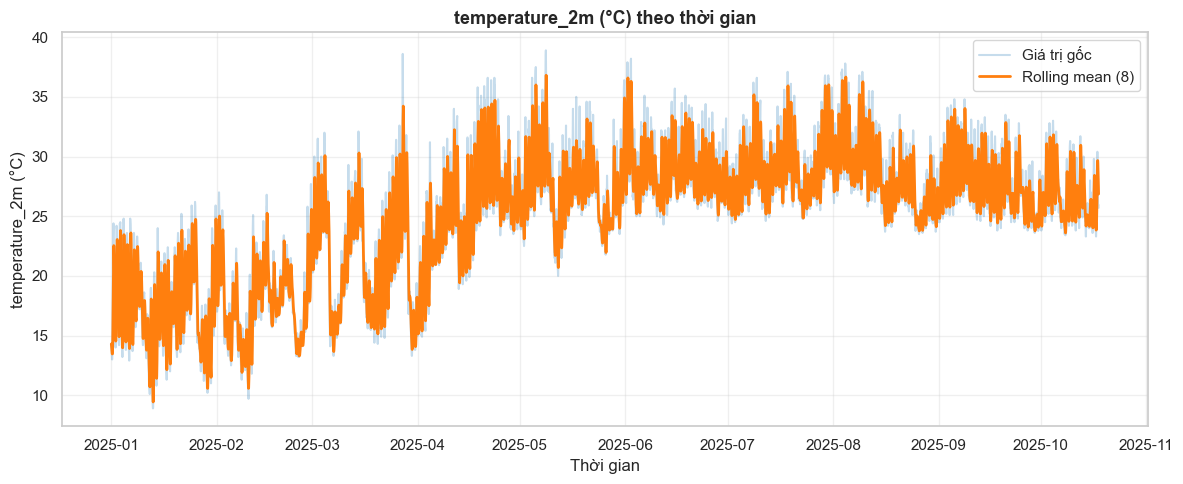


📊 EDA THEO THỜI GIAN: relative_humidity_2m (%)
➡️ Toàn bộ dữ liệu (relative_humidity_2m (%))


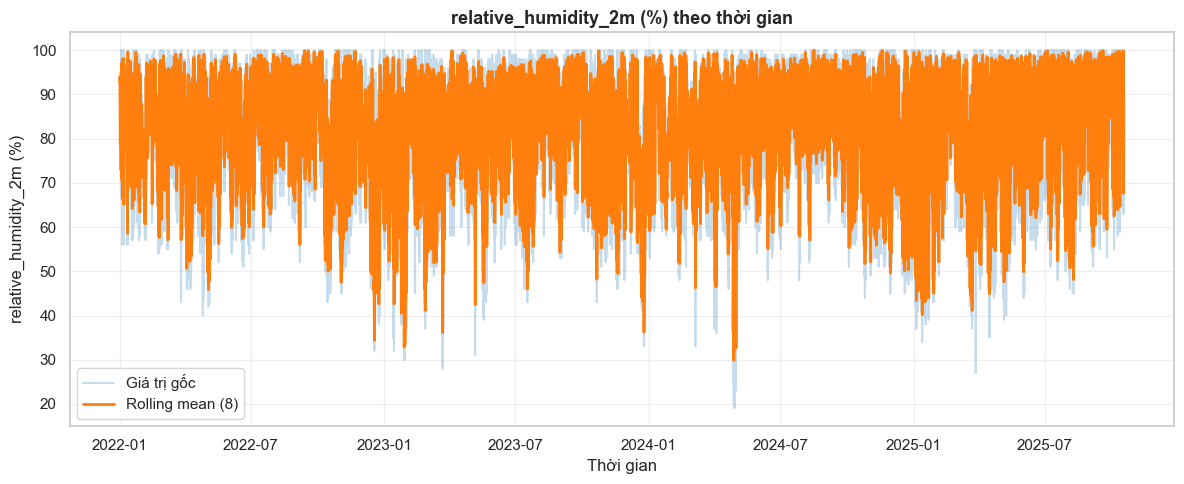


📅 Năm 2022 — cột relative_humidity_2m (%)


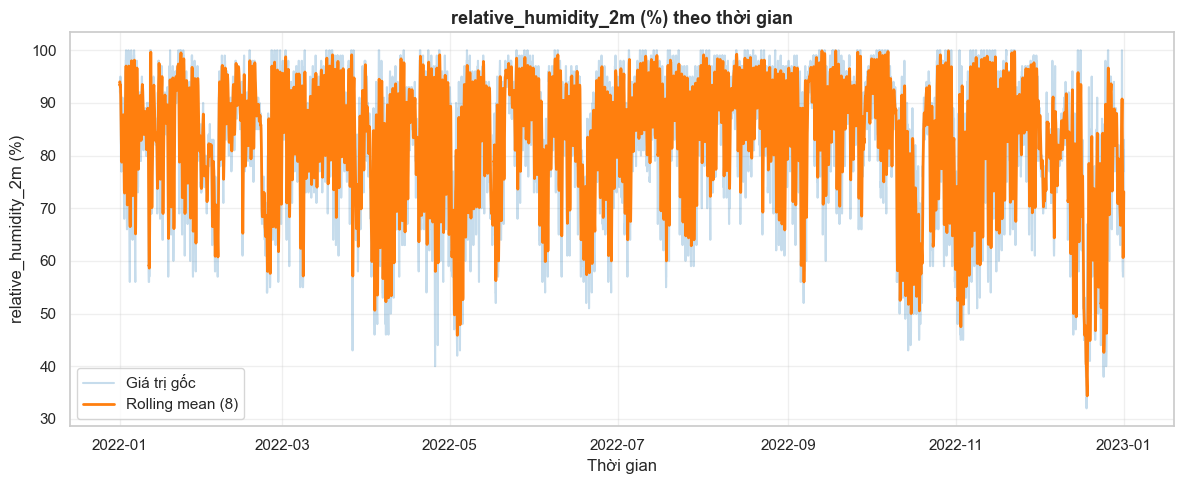


📅 Năm 2023 — cột relative_humidity_2m (%)


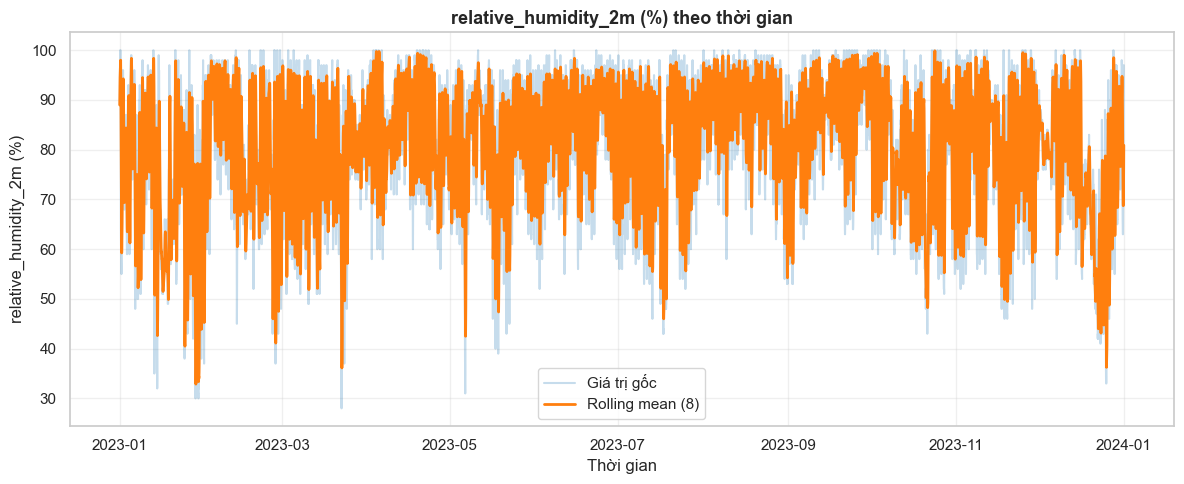


📅 Năm 2024 — cột relative_humidity_2m (%)


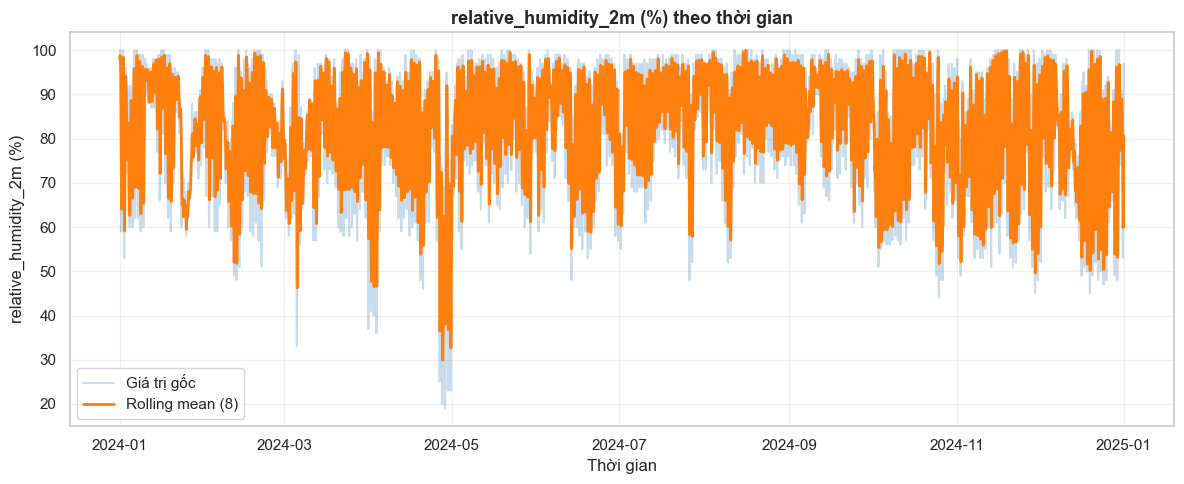


📅 Năm 2025 — cột relative_humidity_2m (%)


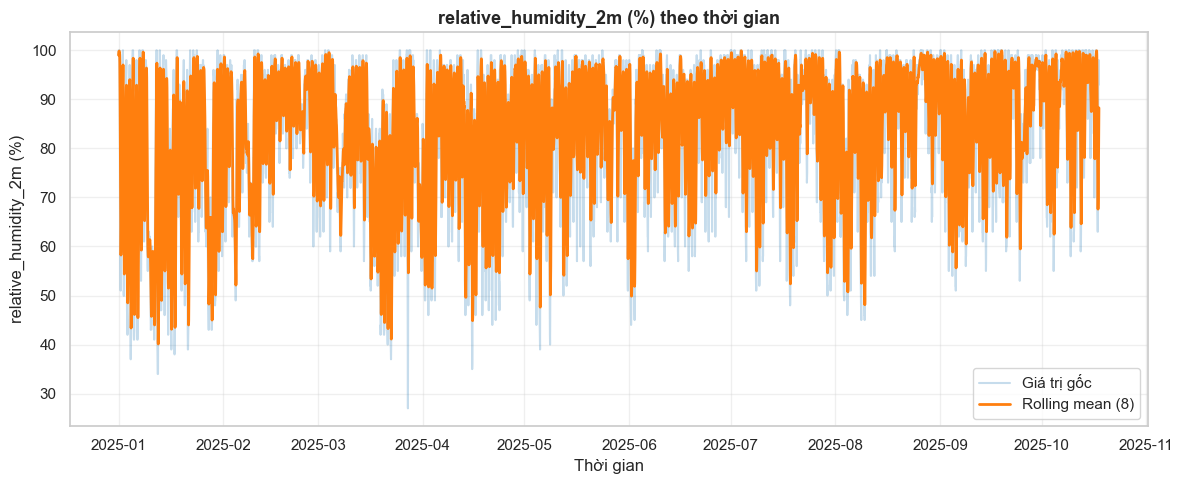


📊 EDA THEO THỜI GIAN: precipitation (mm)
➡️ Toàn bộ dữ liệu (precipitation (mm))


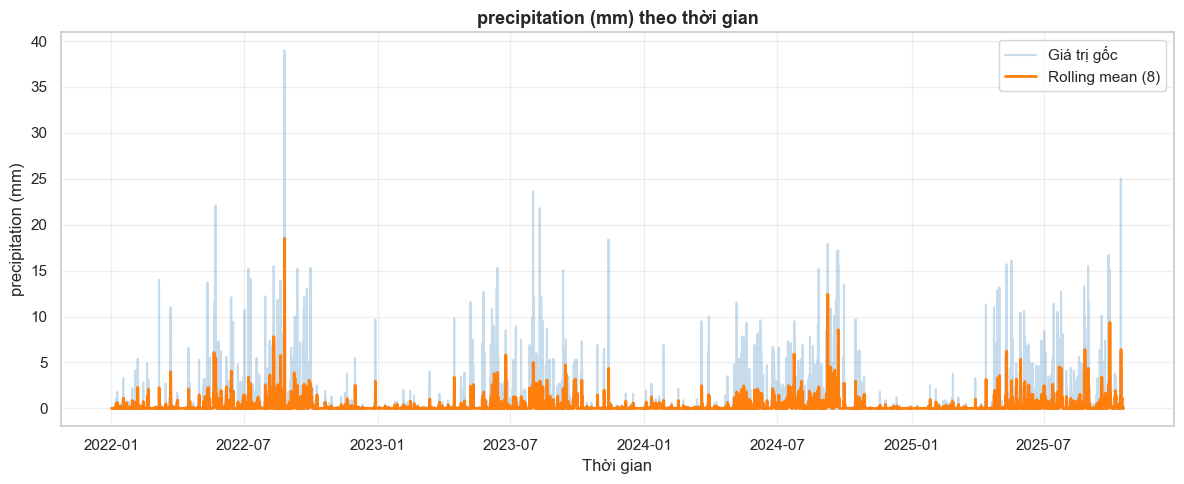


📅 Năm 2022 — cột precipitation (mm)


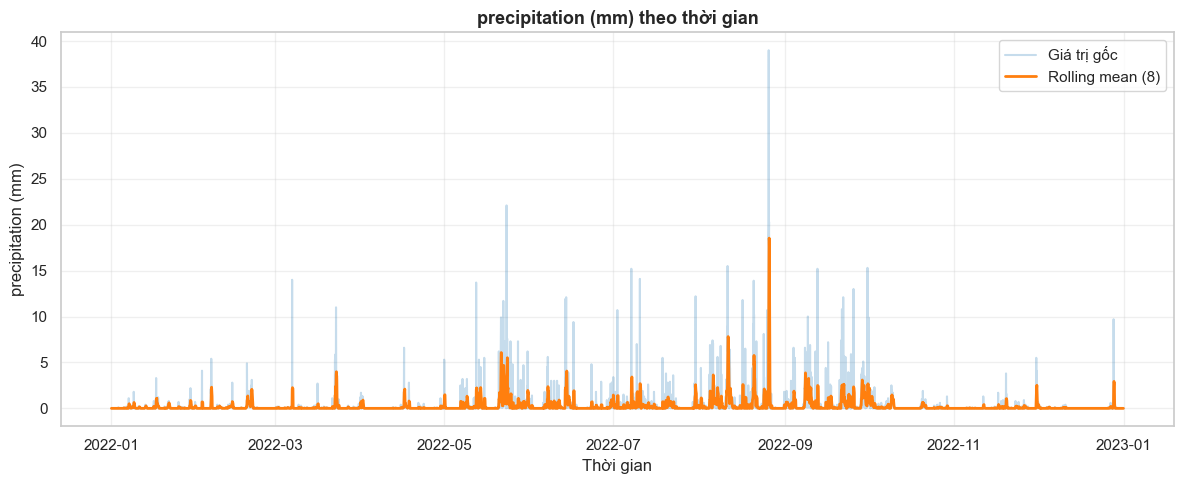


📅 Năm 2023 — cột precipitation (mm)


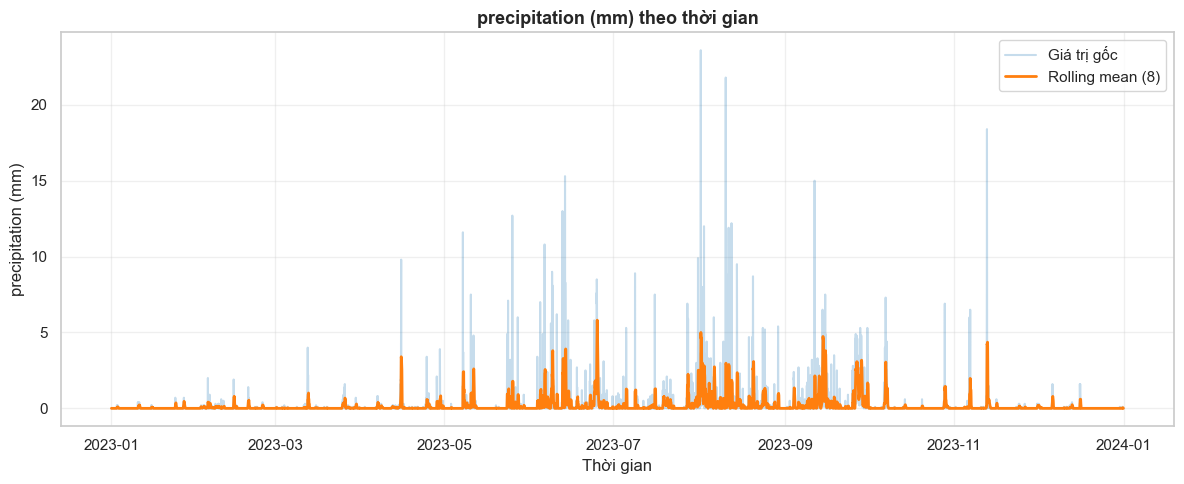


📅 Năm 2024 — cột precipitation (mm)


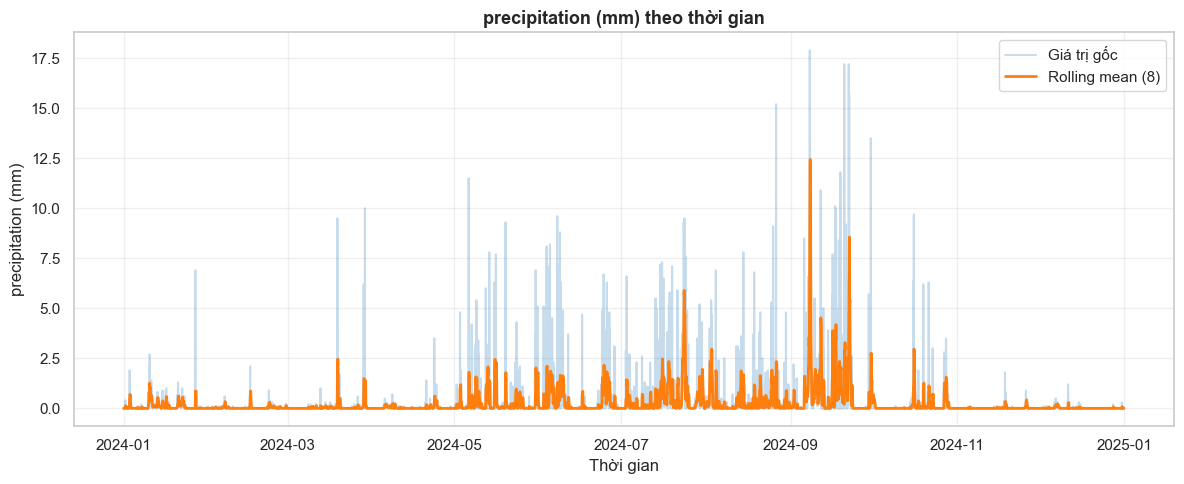


📅 Năm 2025 — cột precipitation (mm)


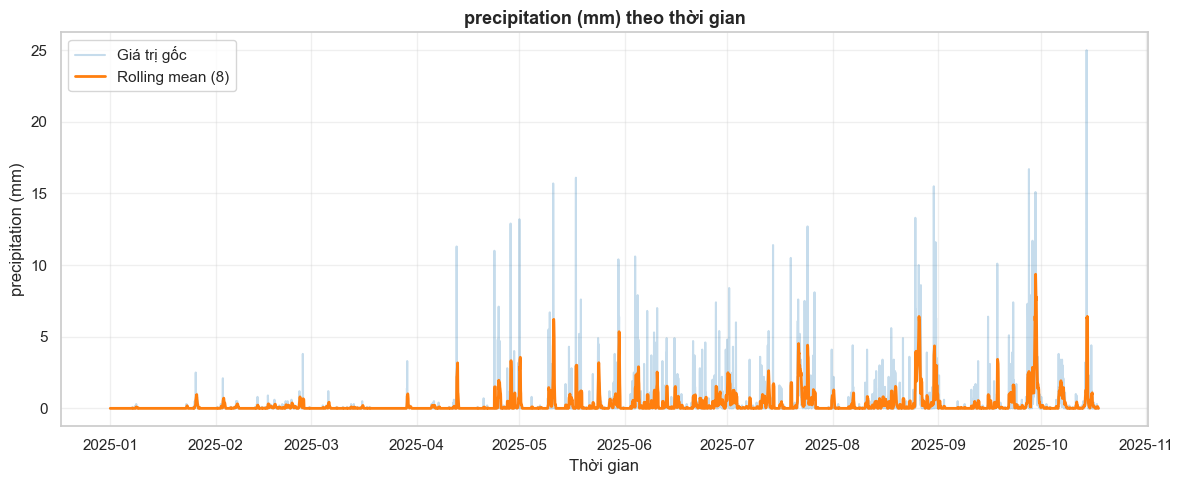


📊 EDA THEO THỜI GIAN: cloud_cover (%)
➡️ Toàn bộ dữ liệu (cloud_cover (%))


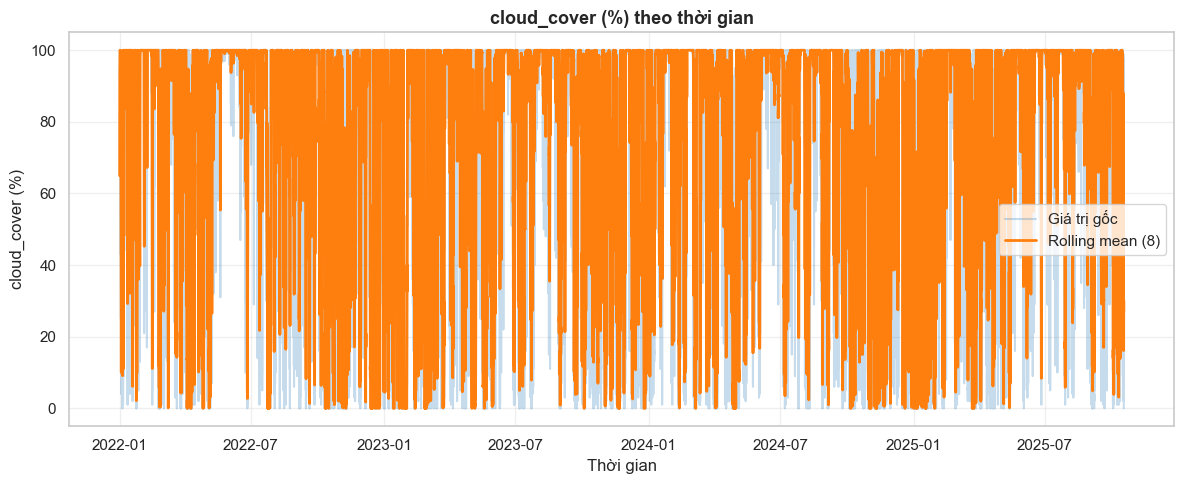


📅 Năm 2022 — cột cloud_cover (%)


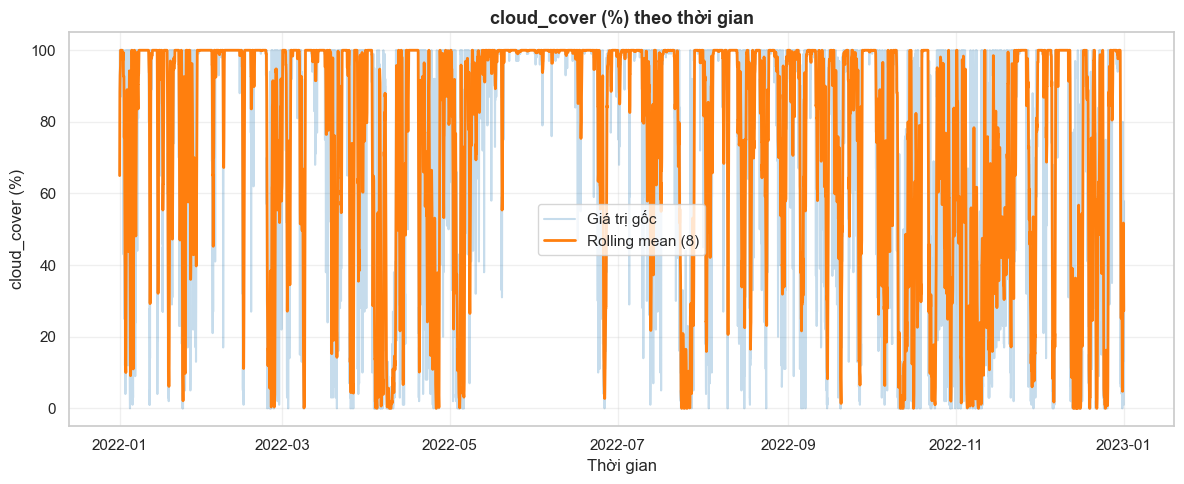


📅 Năm 2023 — cột cloud_cover (%)


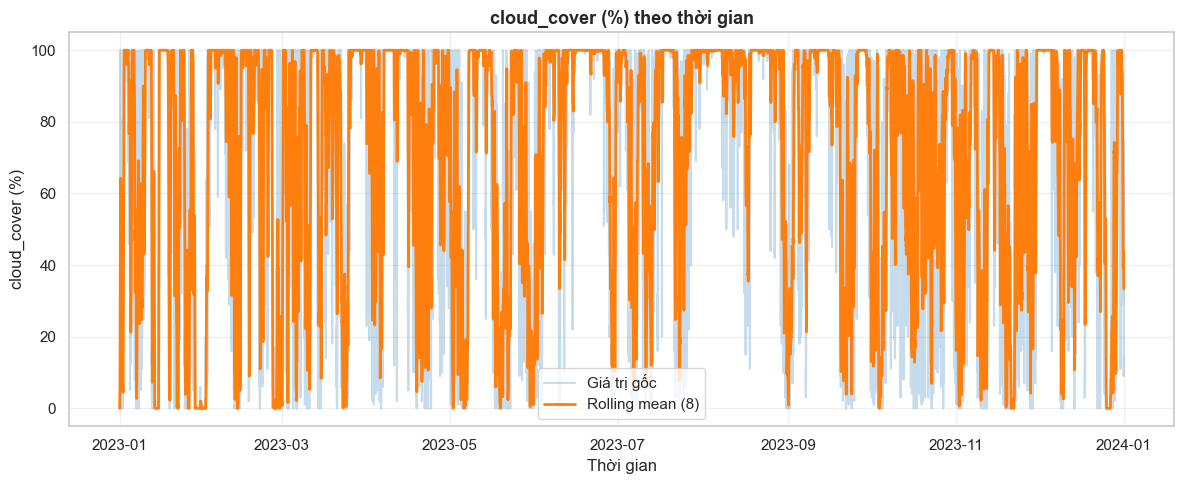


📅 Năm 2024 — cột cloud_cover (%)


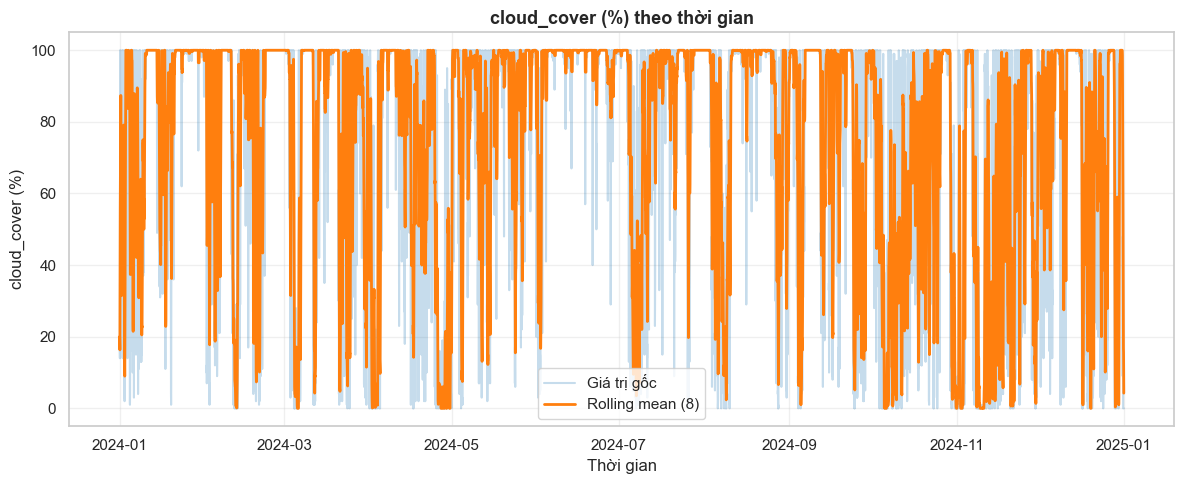


📅 Năm 2025 — cột cloud_cover (%)


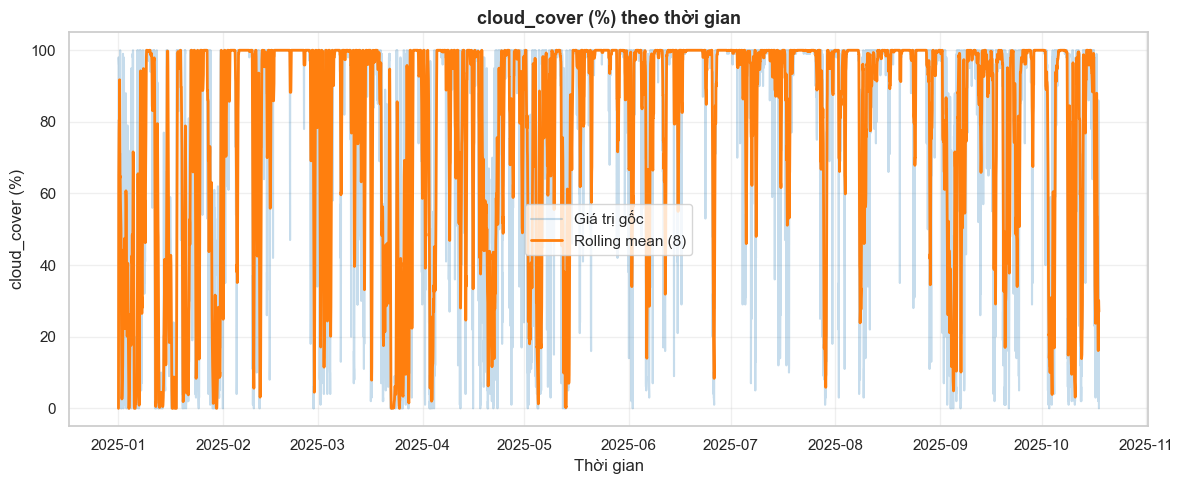

In [21]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

# đảm bảo cột time là datetime
df['time'] = pd.to_datetime(df['time'])

# chạy EDA theo thời gian
run_time_eda(df, cols_target, time_col='time')


### EDA trực quan giữa các feature

#### Các hàm

##### Thống kê

In [22]:
def show_statistics(df, cols_target):
    """
    Hiển thị thống kê mô tả và ma trận tương quan giữa các cột numeric.
    """
    print("📈 Thống kê mô tả:")
    display(df[cols_target].describe().T.round(3))  # Thống kê từng biến

    print("\n🔗 Ma trận tương quan (Pearson):")
    corr = df[cols_target].corr(method='pearson')
    display(corr.round(3))

    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
    plt.title("Ma trận tương quan giữa các biến")
    plt.tight_layout()
    plt.show()

    return corr


##### Scatter

In [23]:
def plot_scatter(df, col_x, col_y, color='tab:blue'):
    """
    Vẽ scatter plot giữa hai cột numeric và hiển thị hệ số tương quan.
    """
    corr_value = df[[col_x, col_y]].corr().iloc[0,1]

    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=col_x, y=col_y, alpha=0.6, color=color)
    sns.regplot(data=df, x=col_x, y=col_y, scatter=False, color='red')
    plt.title(f'{col_y} vs {col_x}\nHệ số tương quan (r) = {corr_value:.3f}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


##### Tổng hợp

In [24]:
def run_pairwise_eda(df, cols_target):
    """
    Chạy EDA đa biến:
    - Thống kê mô tả + ma trận tương quan
    - Scatter plot cho từng cặp cột trong cols_target
    """
    print("==============================")
    print("📊 EDA ĐA BIẾN GIỮA CÁC CỘT")
    print("==============================")

    corr = show_statistics(df, cols_target)

    #n = len(cols_target)
    #for i in range(n):
    #    for j in range(i+1, n):
    #        col_x, col_y = cols_target[i], cols_target[j]
    #        print(f"\n🔹 Cặp biến: {col_x} vs {col_y}")
    #        plot_scatter(df, col_x, col_y)


#### Kết quả

📊 EDA ĐA BIẾN GIỮA CÁC CỘT
📈 Thống kê mô tả:


,count,mean,std,min,25%,50%,75%,max
temperature_2m (°C),33264.0,24.639,5.445,7.4,21.1,25.7,28.3,42.9
relative_humidity_2m (%),33264.0,82.623,13.649,19.0,74.0,86.0,94.0,100.0
precipitation (mm),33264.0,0.242,1.075,0.0,0.0,0.0,0.1,39.0
cloud_cover (%),33264.0,75.604,36.295,0.0,50.0,100.0,100.0,100.0



🔗 Ma trận tương quan (Pearson):


,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),cloud_cover (%)
temperature_2m (°C),1.000,-0.181,0.057,-0.006
relative_humidity_2m (%),-0.181,1.000,0.130,0.218
precipitation (mm),0.057,0.130,1.000,0.139
cloud_cover (%),-0.006,0.218,0.139,1.000


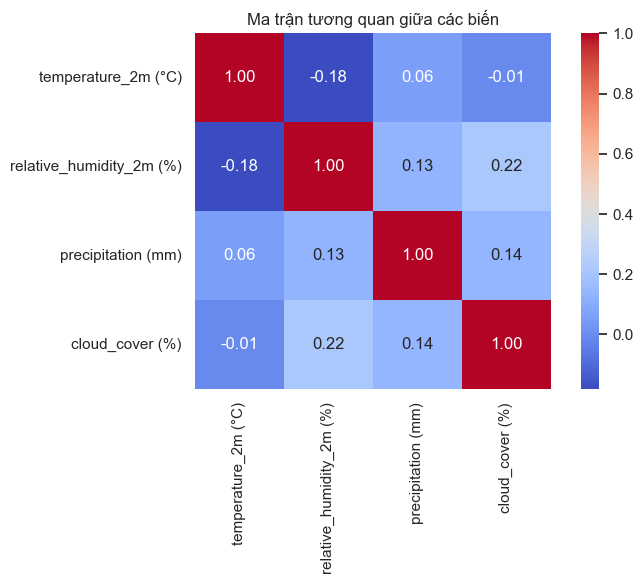

In [25]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

# đảm bảo time là datetime
df['time'] = pd.to_datetime(df['time'])

# chạy EDA đa biến
run_pairwise_eda(df, cols_target)


### Lưu file

#### Hàm lưu

In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# -------------------------------
# 🧱 Hàm hỗ trợ lưu file
# -------------------------------
def save_plot(fig, folder, filename):
    """Lưu biểu đồ vào thư mục"""
    os.makedirs(folder, exist_ok=True)
    fig.savefig(os.path.join(folder, filename), bbox_inches="tight")
    plt.close(fig)

def save_dataframe(df, folder, filename):
    """Lưu DataFrame ra CSV"""
    os.makedirs(folder, exist_ok=True)
    df.to_csv(os.path.join(folder, filename), index=True)

# -------------------------------
# 📊 Thống kê mô tả + Ma trận tương quan
# -------------------------------
def show_statistics_and_save(df, cols_target, output_folder="EDA_Multivariate"):
    """Tính và lưu thống kê mô tả + ma trận tương quan"""
    os.makedirs(output_folder, exist_ok=True)

    # 1️⃣ Thống kê mô tả
    desc = df[cols_target].describe().T.round(3)
    desc["null_count"] = df[cols_target].isna().sum()
    desc_path = os.path.join(output_folder, "statistical_summary.csv")
    desc.to_csv(desc_path)
    print(f"📁 Đã lưu thống kê mô tả: {desc_path}")

    # 2️⃣ Ma trận tương quan
    corr = df[cols_target].corr(method="pearson").round(3)
    corr_path = os.path.join(output_folder, "correlation_matrix.csv")
    corr.to_csv(corr_path)
    print(f"📁 Đã lưu ma trận tương quan: {corr_path}")

    # 3️⃣ Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=ax)
    ax.set_title("Ma trận tương quan giữa các biến", fontsize=13, weight="bold")
    plt.tight_layout()
    save_plot(fig, output_folder, "correlation_heatmap.png")
    print(f"📁 Đã lưu biểu đồ tương quan: correlation_heatmap.png")

    return desc, corr

# -------------------------------
# ⚙️ Hàm chính EDA đa biến
# -------------------------------
def run_pairwise_eda_save(df, cols_target, output_folder="EDA_Multivariate"):
    """
    Chạy EDA đa biến:
    - Lưu thống kê mô tả + ma trận tương quan + heatmap ra file
    """
    print("==============================")
    print("📊 EDA ĐA BIẾN GIỮA CÁC CỘT")
    print("==============================")

    desc, corr = show_statistics_and_save(df, cols_target, output_folder)

    print("\n✅ Hoàn tất EDA đa biến.")
    print(f"📂 Kết quả được lưu trong thư mục: {output_folder}")


In [26]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# -------------------------------
# 🧱 Hàm hỗ trợ lưu biểu đồ
# -------------------------------
def save_plot(fig, folder, filename):
    """Lưu biểu đồ vào thư mục"""
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)
    fig.savefig(filepath, bbox_inches="tight")
    plt.close(fig)

# -------------------------------
# 📈 Vẽ biểu đồ theo thời gian
# -------------------------------
def plot_time_series_save(df, time_col, value_col, folder, smooth_window=8, suffix=""):
    """Vẽ biểu đồ theo thời gian và lưu file"""
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])

    df = df.sort_values(by=time_col)
    df[f"{value_col}_smooth"] = df[value_col].rolling(window=smooth_window, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df[time_col], df[value_col], alpha=0.25, label="Giá trị gốc", color="tab:blue")
    ax.plot(df[time_col], df[f"{value_col}_smooth"], color="tab:orange", lw=2, label=f"Rolling mean ({smooth_window})")

    ax.set_title(f"{value_col} theo thời gian {suffix}", fontsize=13, weight="bold")
    ax.set_xlabel("Thời gian")
    ax.set_ylabel(value_col)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    filename = f"{value_col.replace(' ', '_')}_time{suffix.replace(' ', '_')}.png"
    save_plot(fig, folder, filename)

# -------------------------------
# 🕒 Hàm tổng hợp EDA theo thời gian + lưu file
# -------------------------------
def run_time_eda_save(df, cols_target, time_col="time", years=[2022, 2023, 2024, 2025], output_folder="EDA_TimeSeries"):
    """
    Chạy EDA theo thời gian (time series) cho từng cột trong cols_target,
    và tách riêng theo từng năm.
    Tự động lưu biểu đồ vào file PNG.
    """
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col])

    df["year"] = df[time_col].dt.year

    os.makedirs(output_folder, exist_ok=True)

    for col in cols_target:
        print(f"\n==============================")
        print(f"📊 EDA THEO THỜI GIAN: {col}")
        print(f"==============================")

        col_folder = os.path.join(output_folder, col.replace(" ", "_"))
        os.makedirs(col_folder, exist_ok=True)

        # --- Tổng thể ---
        print(f"➡️ Toàn bộ dữ liệu ({col})")
        plot_time_series_save(df, time_col, col, folder=col_folder, smooth_window=8, suffix="_all")

        # --- Theo từng năm ---
        for y in years:
            if y in df["year"].unique():
                print(f"\n📅 Năm {y} — cột {col}")
                df_year = df[df["year"] == y]
                year_folder = os.path.join(col_folder, str(y))
                os.makedirs(year_folder, exist_ok=True)
                plot_time_series_save(df_year, time_col, col, folder=year_folder, smooth_window=8, suffix=f"_{y}")
            else:
                print(f"⚠️ Không có dữ liệu cho năm {y}.")

    print(f"\n✅ Toàn bộ biểu đồ EDA theo thời gian đã được lưu tại: {output_folder}")


#### Tiến hành lưu

In [27]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

df['time'] = pd.to_datetime(df['time'])

run_pairwise_eda_save(df, cols_target, output_folder="../plot/HoaBinh/DaBien")


📊 EDA ĐA BIẾN GIỮA CÁC CỘT
📁 Đã lưu thống kê mô tả: ../plot/HoaBinh/DaBien\statistical_summary.csv
📁 Đã lưu ma trận tương quan: ../plot/HoaBinh/DaBien\correlation_matrix.csv
📁 Đã lưu biểu đồ tương quan: correlation_heatmap.png

✅ Hoàn tất EDA đa biến.
📂 Kết quả được lưu trong thư mục: ../plot/HoaBinh/DaBien


In [28]:
cols_target = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'cloud_cover (%)'
]

df['time'] = pd.to_datetime(df['time'])

run_time_eda_save(df, cols_target, time_col='time', output_folder="../plot/HoaBinh/DaBien")



📊 EDA THEO THỜI GIAN: temperature_2m (°C)
➡️ Toàn bộ dữ liệu (temperature_2m (°C))

📅 Năm 2022 — cột temperature_2m (°C)

📅 Năm 2023 — cột temperature_2m (°C)

📅 Năm 2024 — cột temperature_2m (°C)

📅 Năm 2025 — cột temperature_2m (°C)

📊 EDA THEO THỜI GIAN: relative_humidity_2m (%)
➡️ Toàn bộ dữ liệu (relative_humidity_2m (%))

📅 Năm 2022 — cột relative_humidity_2m (%)

📅 Năm 2023 — cột relative_humidity_2m (%)

📅 Năm 2024 — cột relative_humidity_2m (%)

📅 Năm 2025 — cột relative_humidity_2m (%)

📊 EDA THEO THỜI GIAN: precipitation (mm)
➡️ Toàn bộ dữ liệu (precipitation (mm))

📅 Năm 2022 — cột precipitation (mm)

📅 Năm 2023 — cột precipitation (mm)

📅 Năm 2024 — cột precipitation (mm)

📅 Năm 2025 — cột precipitation (mm)

📊 EDA THEO THỜI GIAN: cloud_cover (%)
➡️ Toàn bộ dữ liệu (cloud_cover (%))

📅 Năm 2022 — cột cloud_cover (%)

📅 Năm 2023 — cột cloud_cover (%)

📅 Năm 2024 — cột cloud_cover (%)

📅 Năm 2025 — cột cloud_cover (%)

✅ Toàn bộ biểu đồ EDA theo thời gian đã được lưu tại: .

# Tổng kết

## 📊 Nhận xét EDA theo tháng

### 🌡️ **Nhiệt độ (`temperature_2m (°C)`)**
- Nhiệt độ trung bình **thấp vào đầu năm (tháng 1–2)**.  
- **Tăng dần từ tháng 3**, đạt **đỉnh vào khoảng tháng 7**,  
- Sau đó **giảm dần về cuối năm**, thể hiện **chu kỳ mùa nóng – lạnh rõ ràng**.

### 🌧️ **Lượng mưa (`precipitation (mm)`)**
- **Mùa mưa kéo dài từ tháng 5 đến tháng 10**, với lượng mưa trung bình cao hơn hẳn các tháng còn lại.  
- **Tháng 11–4** là **mùa khô**, lượng mưa thấp và ổn định hơn.

### ☁️ **Độ che phủ mây (`cloud_cover (%)`)**  
- Biểu đồ không thể hiện xu hướng rõ ràng theo tháng.  
- Có thể biến động do yếu tố thời tiết ngắn hạn hoặc khu vực, **nên giữ lại để phân tích sâu hơn ở bước sau**.

### 💧 **Độ ẩm tương đối (`relative_humidity_2m (%)`)**  
- Xu hướng theo tháng **không rõ ràng hoặc dao động nhẹ**.  
- Có thể chịu ảnh hưởng gián tiếp từ lượng mưa và nhiệt độ,  
  **nên cũng được giữ lại để xử lý trong giai đoạn tiền xử lý & mô hình hóa**.

---

✅ **Tổng kết:**  
- `temperature_2m (°C)` và `precipitation (mm)` cho thấy **mùa vụ rõ rệt**, phù hợp để dùng làm **biến giải thích chính** trong mô hình.  
- `cloud_cover (%)` và `relative_humidity_2m (%)` chưa có xu hướng mạnh, nhưng **nên giữ lại để kiểm tra tương tác hoặc phi tuyến** sau này.
